Imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import time

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


 Load Dataset

In [ ]:
df = pd.read_csv("warehouse_retrieval_50k_updated.csv")
TARGET = "retrieval_time_minutes"

print(f"Shape  : {df.shape}")
print(f"Target : {TARGET}")
df.head()

Shape  : (52000, 21)
Target : retrieval_time_minutes


,request_date,request_timestamp,warehouse_zone,aisle_number,shelf_level,distance_from_dock_meters,storage_type,active_retrievals_count,dock_queue_length,aisle_traffic_level,...,day_of_week,num_packages,total_weight_kg,requires_forklift,fragile_handling,num_aisles_to_visit,special_equipment_needed,operator_experience_years,operator_shift_fatigue,retrieval_time_minutes
0,2025-06-17,2025-06-17 08:57:32,Zone_C,10,Mid,321.0,pallet_rack,16,6.0,High,...,Tuesday,45,39.3,False,True,2,none,0.9,4.1,120.37
1,2025-07-21,2025-07-21 20:50:49,Zone_C,34,Mid,230.3,pallet_rack,16,7.0,Medium,...,Monday,6,89.6,True,False,1,none,4.8,2.5,69.82
2,2025-10-03,2025-10-03 21:52:15,Zone_A,19,Mid,18.3,bulk_floor,9,5.0,Medium,...,Friday,4,79.5,False,False,2,none,15.8,1.2,38.04
3,2025-09-17,2025-09-17 18:31:18,Zone_A,16,Floor,42.5,pallet_rack,25,19.0,High,...,Wednesday,11,601.6,True,False,7,cold_gear,3.5,8.7,260.89
4,2025-11-10,2025-11-10 21:34:27,Zone_A,47,Floor,14.1,pallet_rack,21,7.0,Low,...,Monday,2,153.3,True,True,4,none,2.8,3.1,85.03


 EDA

In [52]:
print("Shape   :", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape   : (52000, 21)

Data Types:
request_date                  object
request_timestamp             object
warehouse_zone                object
aisle_number                   int64
shelf_level                   object
distance_from_dock_meters    float64
storage_type                  object
active_retrievals_count        int64
dock_queue_length            float64
aisle_traffic_level           object
shift_hour                     int64
day_of_week                   object
num_packages                   int64
total_weight_kg              float64
requires_forklift               bool
fragile_handling              object
num_aisles_to_visit            int64
special_equipment_needed      object
operator_experience_years    float64
operator_shift_fatigue       float64
retrieval_time_minutes       float64
dtype: object

Basic Statistics:


,aisle_number,distance_from_dock_meters,active_retrievals_count,dock_queue_length,shift_hour,num_packages,total_weight_kg,num_aisles_to_visit,operator_experience_years,operator_shift_fatigue,retrieval_time_minutes
count,52000.000000,52000.000000,52000.000000,51271.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,51191.000000,52000.000000
mean,25.565365,201.425294,14.080981,7.439293,13.296904,18.521942,185.710117,2.795731,4.953913,5.992305,109.405843
std,14.400837,128.191471,7.797555,5.430169,5.945041,17.973593,319.849768,2.047308,4.810338,3.471247,52.170109
min,1.000000,5.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,10.790000
25%,13.000000,92.900000,8.000000,3.000000,9.000000,6.000000,40.300000,1.000000,1.400000,3.000000,71.077500
50%,26.000000,183.800000,14.000000,7.000000,14.000000,13.000000,89.900000,2.000000,3.500000,6.000000,100.005000
75%,38.000000,299.400000,20.000000,11.000000,18.000000,25.000000,199.300000,4.000000,6.900000,9.000000,137.542500
max,50.000000,500.000000,40.000000,25.000000,23.000000,200.000000,5000.000000,10.000000,25.000000,12.000000,280.000000


### 3.1 Missing Values

In [53]:
miss     = df.isnull().sum()
miss_pct = (df.isnull().mean() * 100).round(2)
miss_df  = pd.DataFrame({"Missing Count": miss, "Missing %": miss_pct})
miss_df  = miss_df[miss_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print(miss_df)

                        Missing Count  Missing %
operator_shift_fatigue            809       1.56
aisle_traffic_level               775       1.49
dock_queue_length                 729       1.40
fragile_handling                  724       1.39


### 3.2 Chart 1 — Target Variable Distribution
> Understand shape, skewness and spread of what we are predicting.

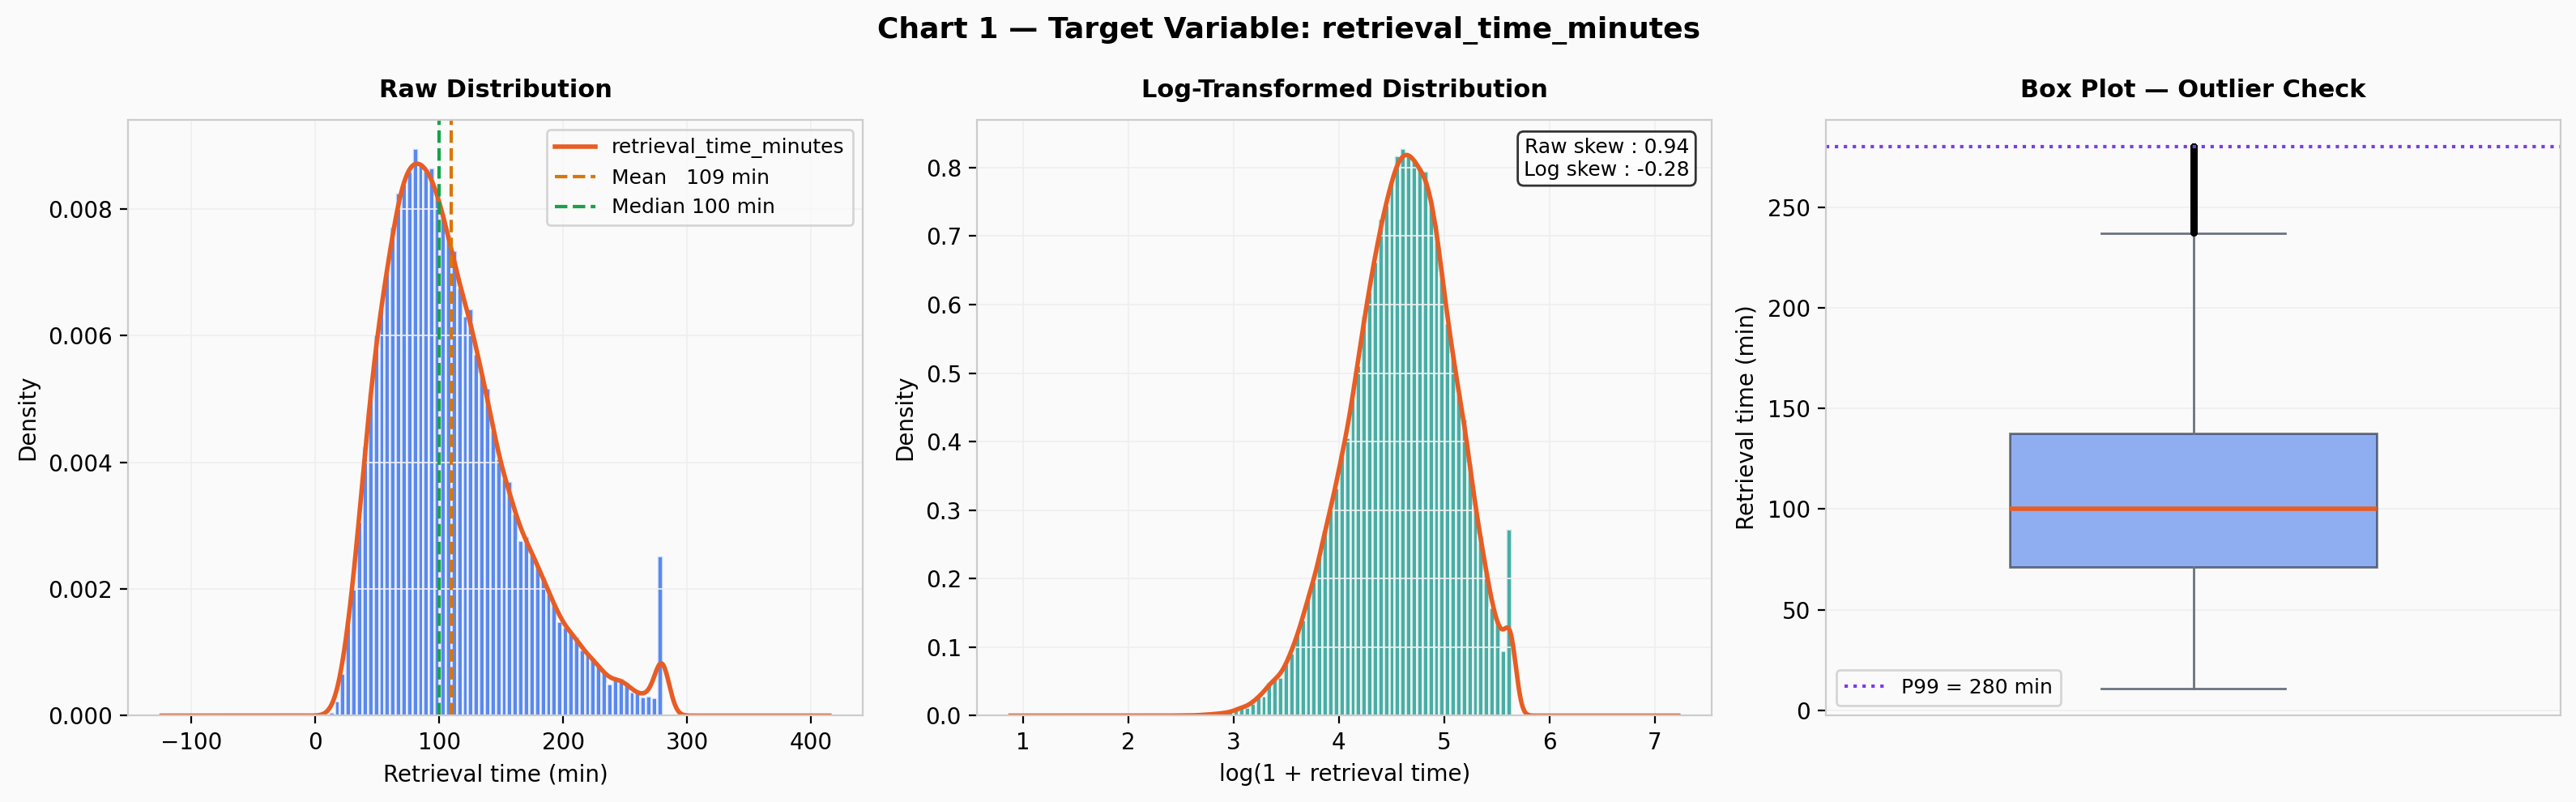

Skewness: 0.941 | Min: 10.8 | Max: 280.0 | Std: 52.2


In [54]:
BLUE="#2563EB"; TEAL="#0D9488"; AMBER="#D97706"
CORAL="#E85D24"; PURPLE="#7C3AED"; GREEN="#16A34A"; GRAY="#6B7280"

plt.rcParams.update({
    "figure.facecolor":"#FAFAFA", "axes.facecolor":"#FAFAFA",
    "axes.edgecolor":"#CCCCCC",   "axes.grid":True,
    "grid.color":"#EEEEEE",       "grid.linewidth":0.6,
    "font.size":10,               "axes.titlesize":11,
    "axes.titleweight":"bold",    "axes.titlepad":10,
})

t   = df[TARGET]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 1 — Target Variable: retrieval_time_minutes",
             fontsize=13, fontweight="bold")

# Raw distribution
ax = axes[0]
ax.hist(t, bins=60, color=BLUE, alpha=0.75, edgecolor="white", density=True)
t.plot.kde(ax=ax, color=CORAL, linewidth=2)
ax.axvline(t.mean(),   color=AMBER, linestyle="--", linewidth=1.5, label=f"Mean   {t.mean():.0f} min")
ax.axvline(t.median(), color=GREEN, linestyle="--", linewidth=1.5, label=f"Median {t.median():.0f} min")
ax.set_title("Raw Distribution")
ax.set_xlabel("Retrieval time (min)"); ax.set_ylabel("Density")
ax.legend(fontsize=9)

# Log transformed
ax    = axes[1]
log_t = np.log1p(t)
ax.hist(log_t, bins=60, color=TEAL, alpha=0.75, edgecolor="white", density=True)
log_t.plot.kde(ax=ax, color=CORAL, linewidth=2)
ax.set_title("Log-Transformed Distribution")
ax.set_xlabel("log(1 + retrieval time)"); ax.set_ylabel("Density")
ax.text(0.97, 0.97, f"Raw skew : {t.skew():.2f}\nLog skew : {log_t.skew():.2f}",
        transform=ax.transAxes, va="top", ha="right", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Boxplot
ax = axes[2]
ax.boxplot(t, patch_artist=True, widths=0.5,
           boxprops=dict(facecolor=BLUE, alpha=0.5),
           medianprops=dict(color=CORAL, linewidth=2),
           whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
           flierprops=dict(marker="o", color=AMBER, markersize=2, alpha=0.4))
ax.set_title("Box Plot — Outlier Check")
ax.set_ylabel("Retrieval time (min)"); ax.set_xticks([])
pct99 = np.percentile(t, 99)
ax.axhline(pct99, color=PURPLE, linestyle=":", linewidth=1.5, label=f"P99 = {pct99:.0f} min")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"Skewness: {t.skew():.3f} | Min: {t.min():.1f} | Max: {t.max():.1f} | Std: {t.std():.1f}")

### 3.3 Chart 2 — Categorical Features vs Retrieval Time
> Which categories cause the longest retrieval delays?

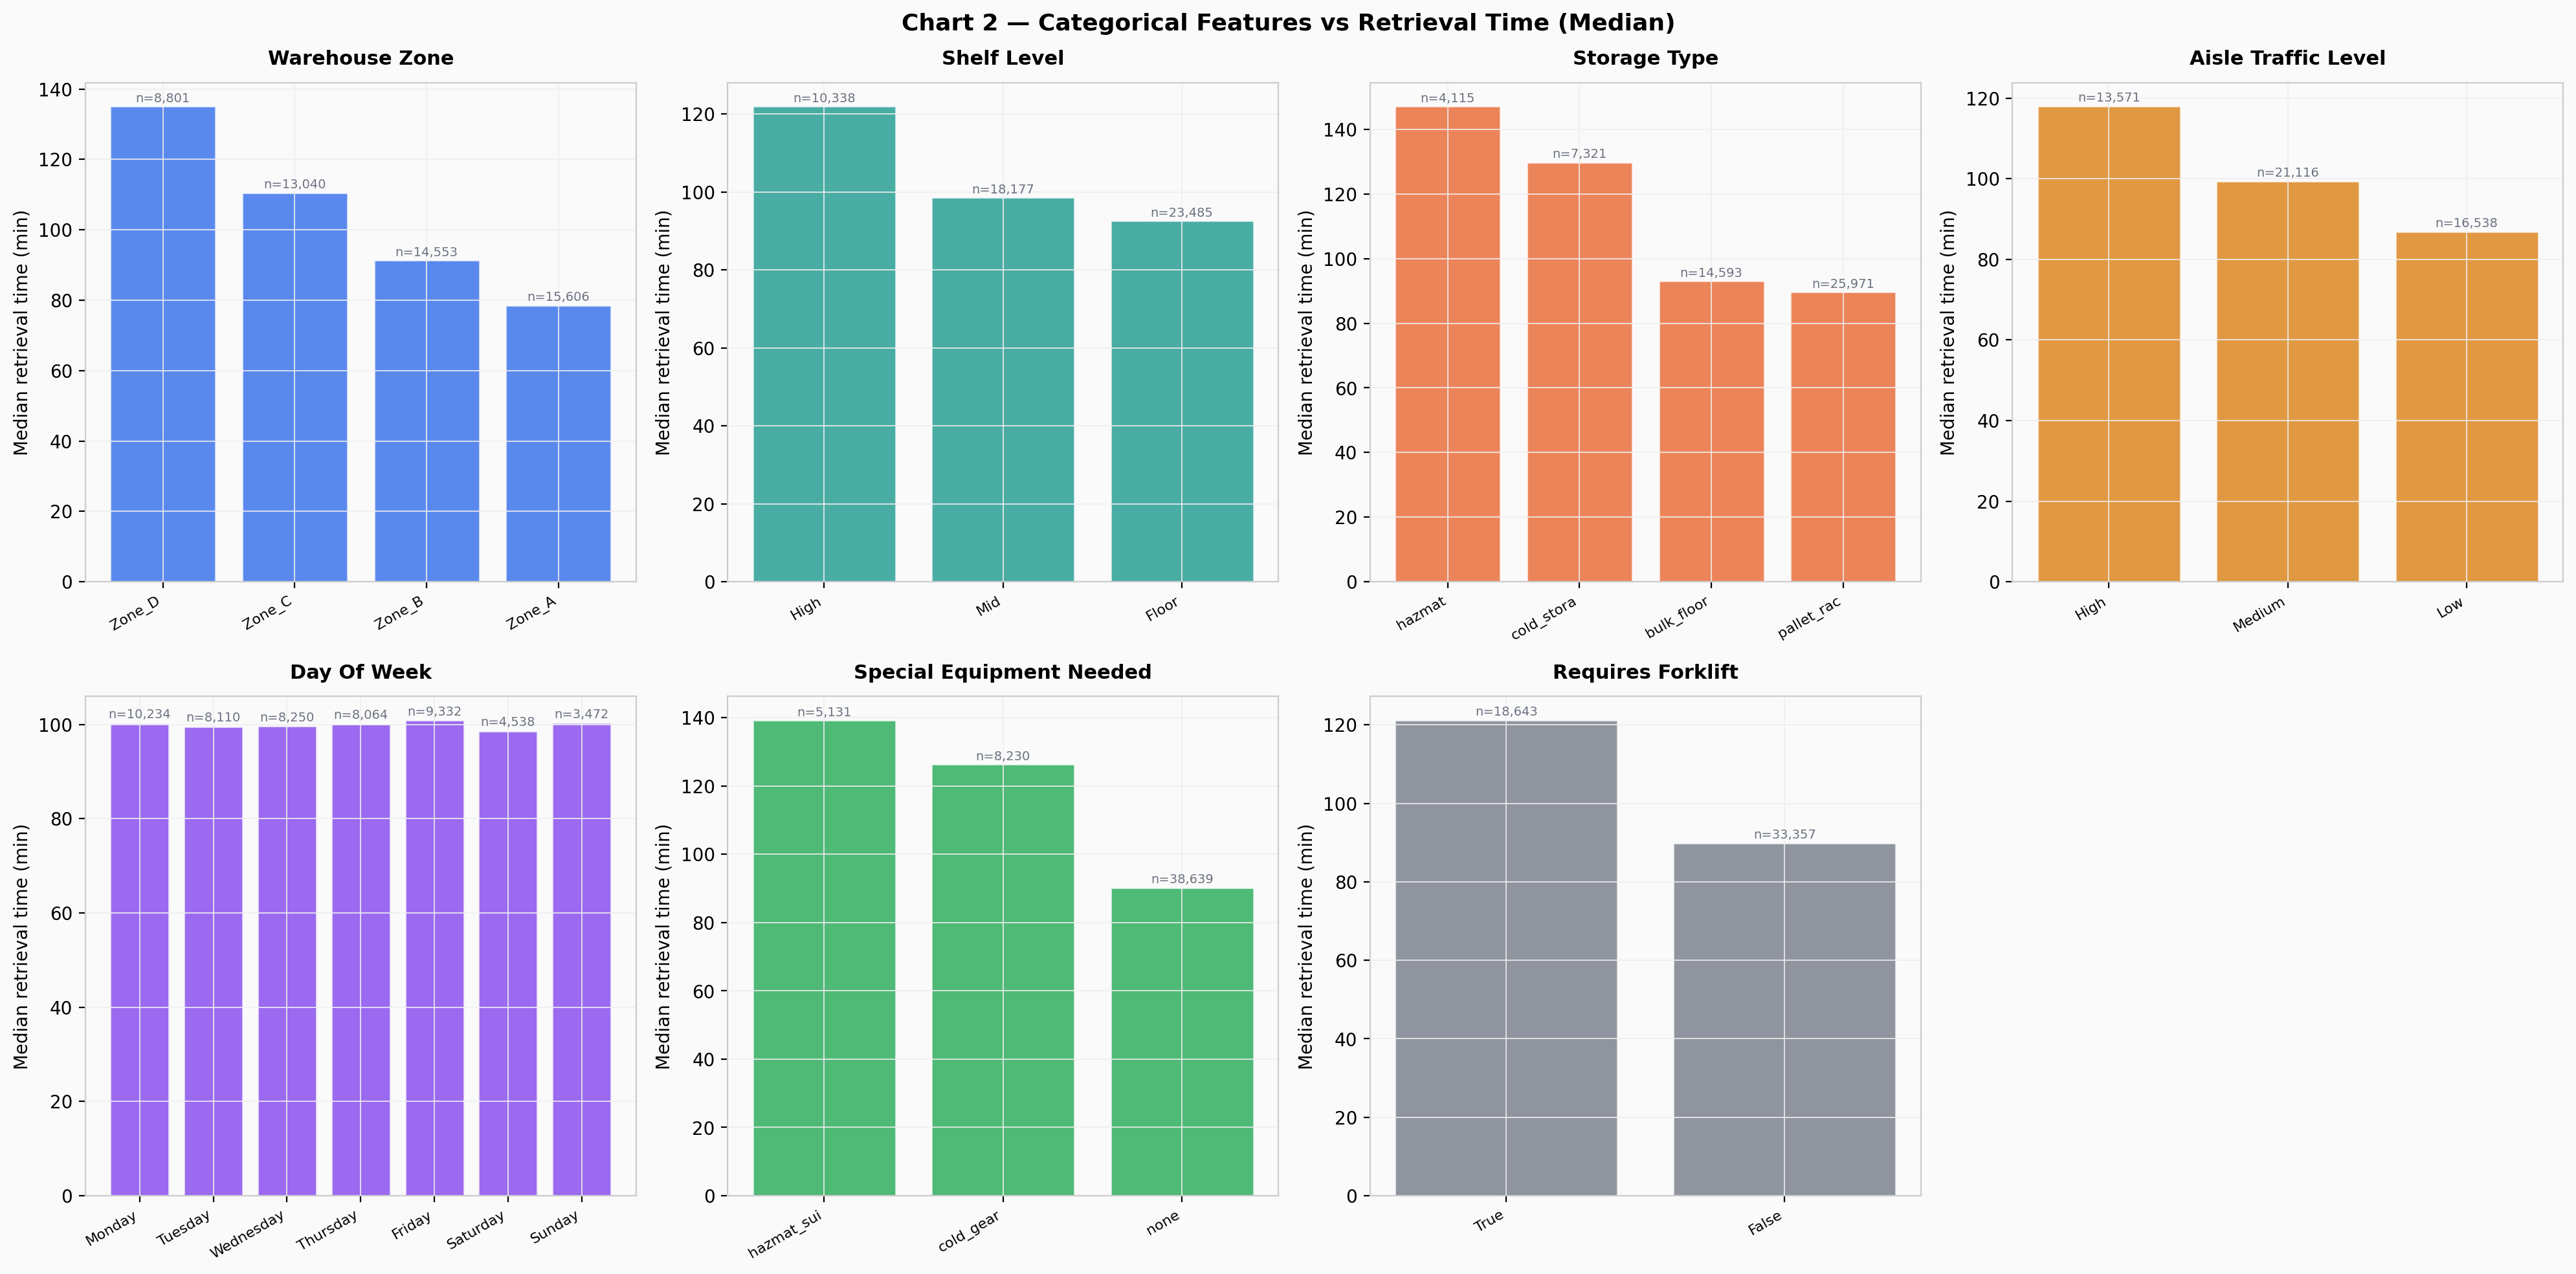

In [55]:
dow_order    = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
cat_features = ["warehouse_zone","shelf_level","storage_type","aisle_traffic_level",
                "day_of_week","special_equipment_needed","requires_forklift"]
colors_map   = {
    "warehouse_zone":BLUE,   "shelf_level":TEAL,
    "storage_type":CORAL,    "aisle_traffic_level":AMBER,
    "day_of_week":PURPLE,    "special_equipment_needed":GREEN,
    "requires_forklift":GRAY
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Chart 2 — Categorical Features vs Retrieval Time (Median)",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    ax    = axes[idx]
    tmp   = df[[col, TARGET]].dropna()
    order = ([d for d in dow_order if d in tmp[col].unique()] if col == "day_of_week"
             else tmp.groupby(col)[TARGET].median().sort_values(ascending=False).index.tolist())
    medians = tmp.groupby(col)[TARGET].median().reindex(order)
    counts  = tmp.groupby(col)[TARGET].count().reindex(order)
    bars    = ax.bar(range(len(order)), medians.values,
                     color=colors_map[col], alpha=0.75, edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([str(o)[:10] for o in order], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Median retrieval time (min)")
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"n={cnt:,}", ha="center", va="bottom", fontsize=7, color=GRAY)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

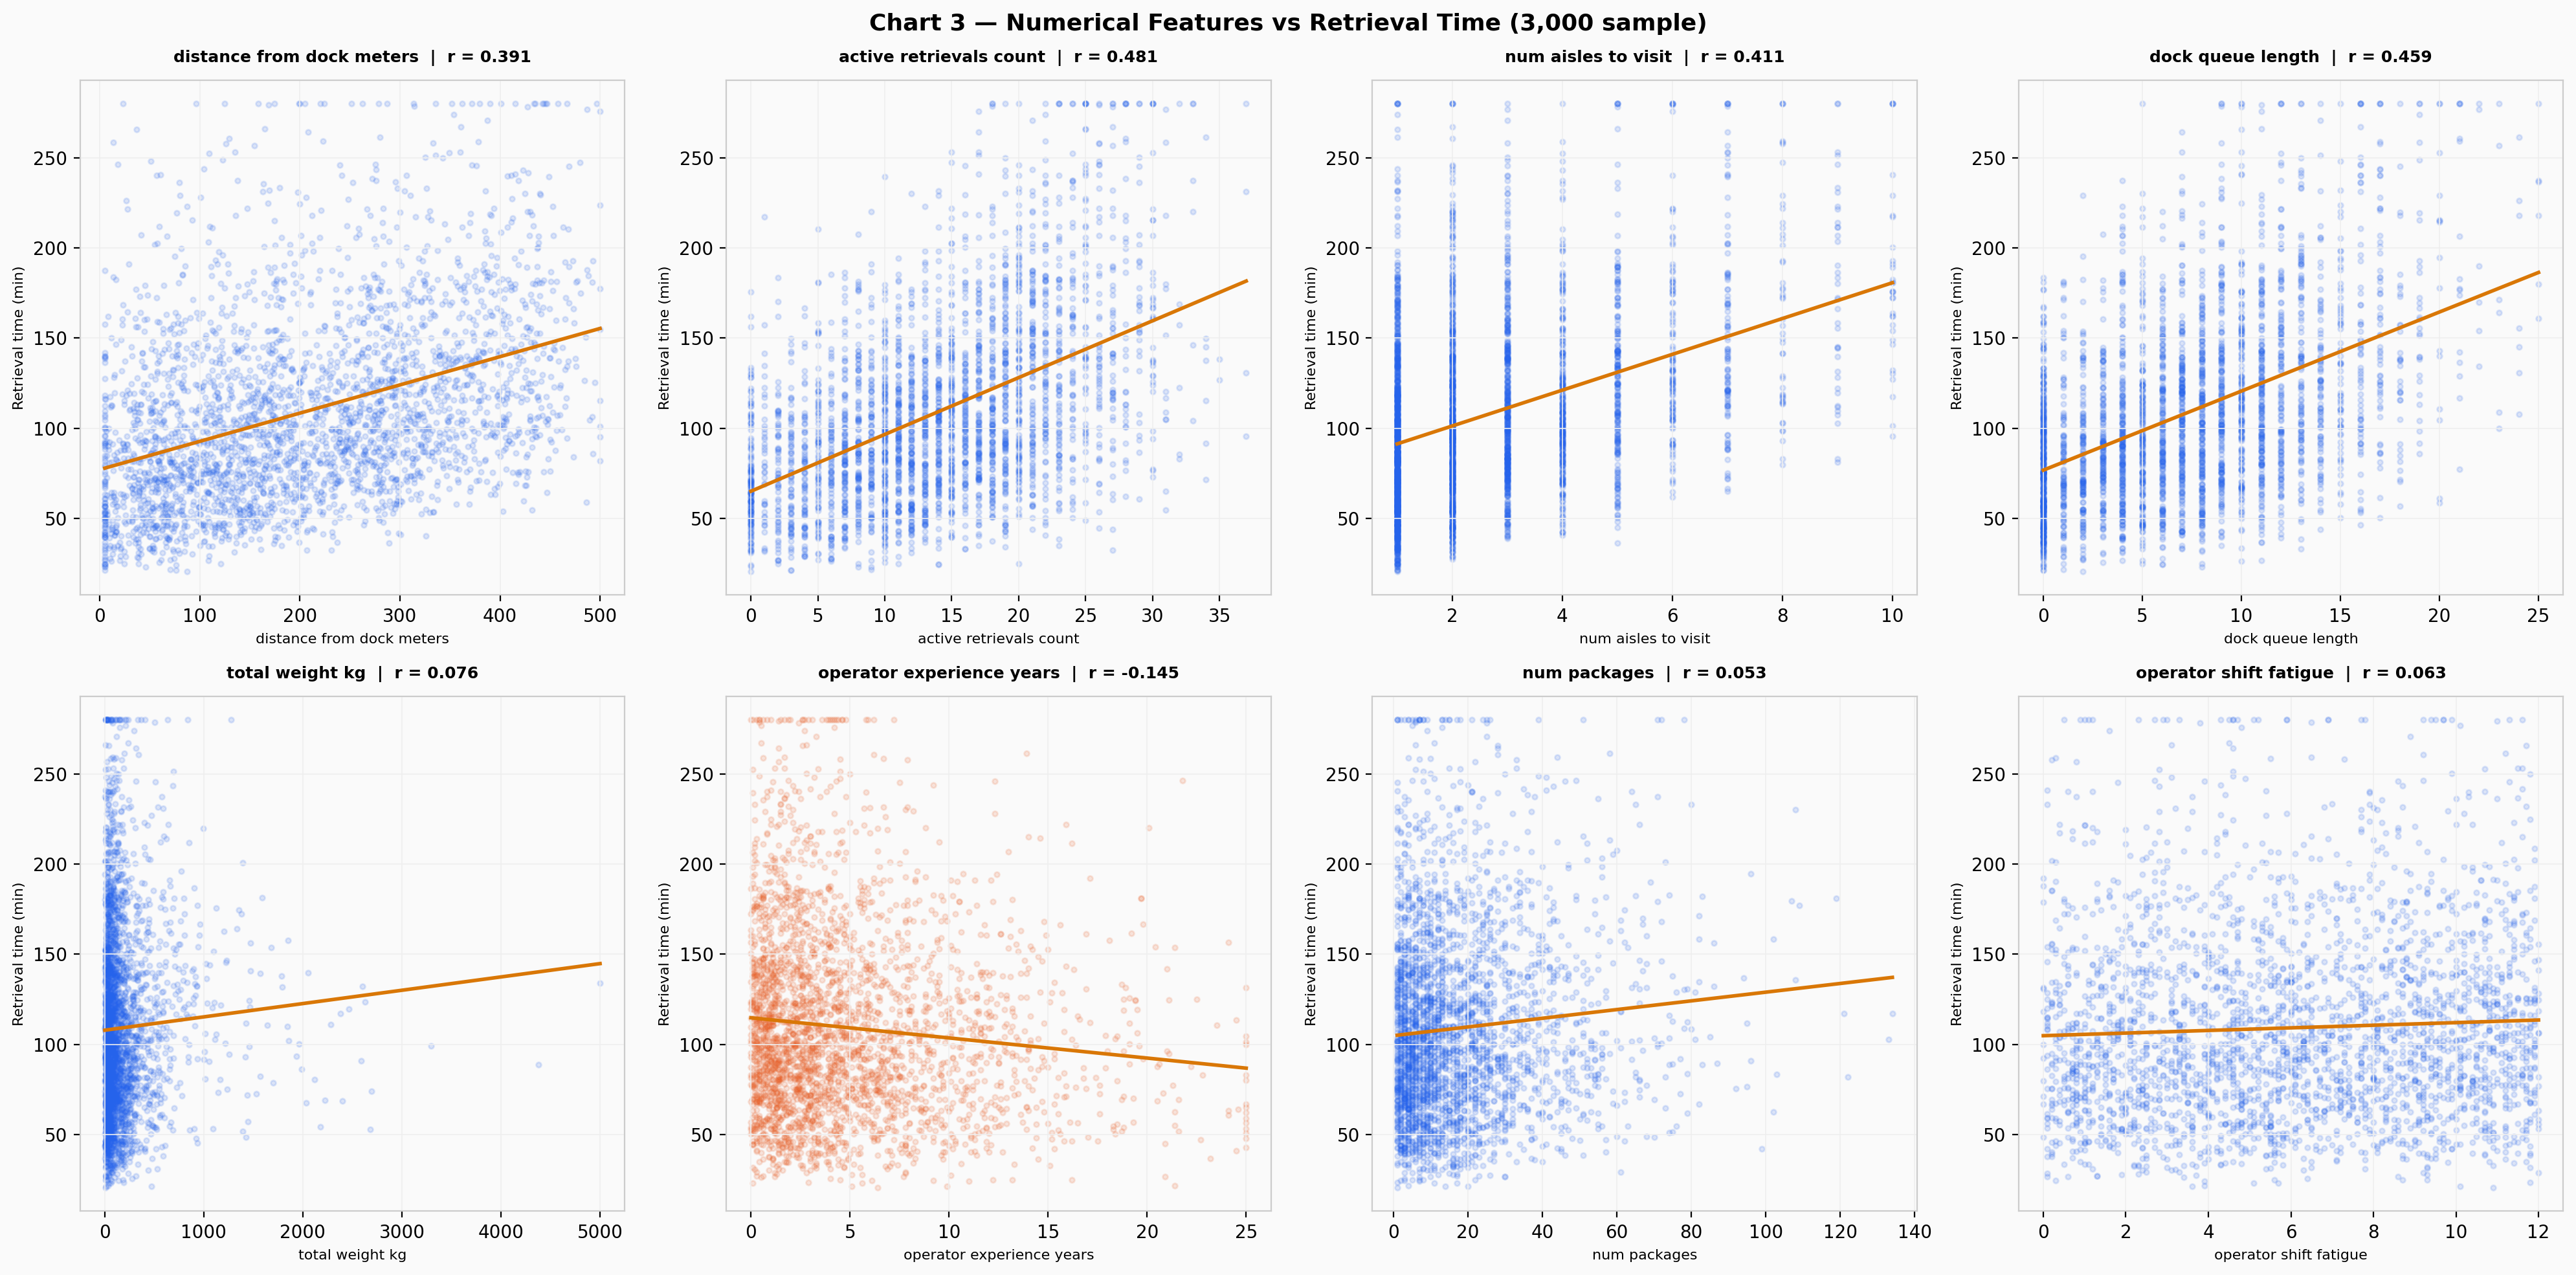

In [56]:
num_features = ["distance_from_dock_meters","active_retrievals_count",
                "num_aisles_to_visit","dock_queue_length","total_weight_kg",
                "operator_experience_years","num_packages","operator_shift_fatigue"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Chart 3 — Numerical Features vs Retrieval Time (3,000 sample)",
             fontsize=13, fontweight="bold")
axes   = axes.flatten()
sample = df.sample(3000, random_state=42)

for idx, col in enumerate(num_features):
    ax   = axes[idx]
    s    = sample[[col, TARGET]].dropna()
    corr = df[[col, TARGET]].dropna().corr()[TARGET][col]
    c    = BLUE if corr >= 0 else CORAL
    ax.scatter(s[col], s[TARGET], alpha=0.15, s=8, color=c)
    z      = np.polyfit(s[col], s[TARGET], 1)
    x_line = np.linspace(s[col].min(), s[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color=AMBER, linewidth=2)
    ax.set_xlabel(col.replace("_", " "), fontsize=8)
    ax.set_ylabel("Retrieval time (min)", fontsize=8)
    ax.set_title(f"{col.replace('_',' ')}  |  r = {corr:.3f}", fontsize=9)

plt.tight_layout()
plt.show()

### 3.5 Chart 4 — Correlation Heatmap
> Find features most correlated with the target and with each other (multicollinearity check).

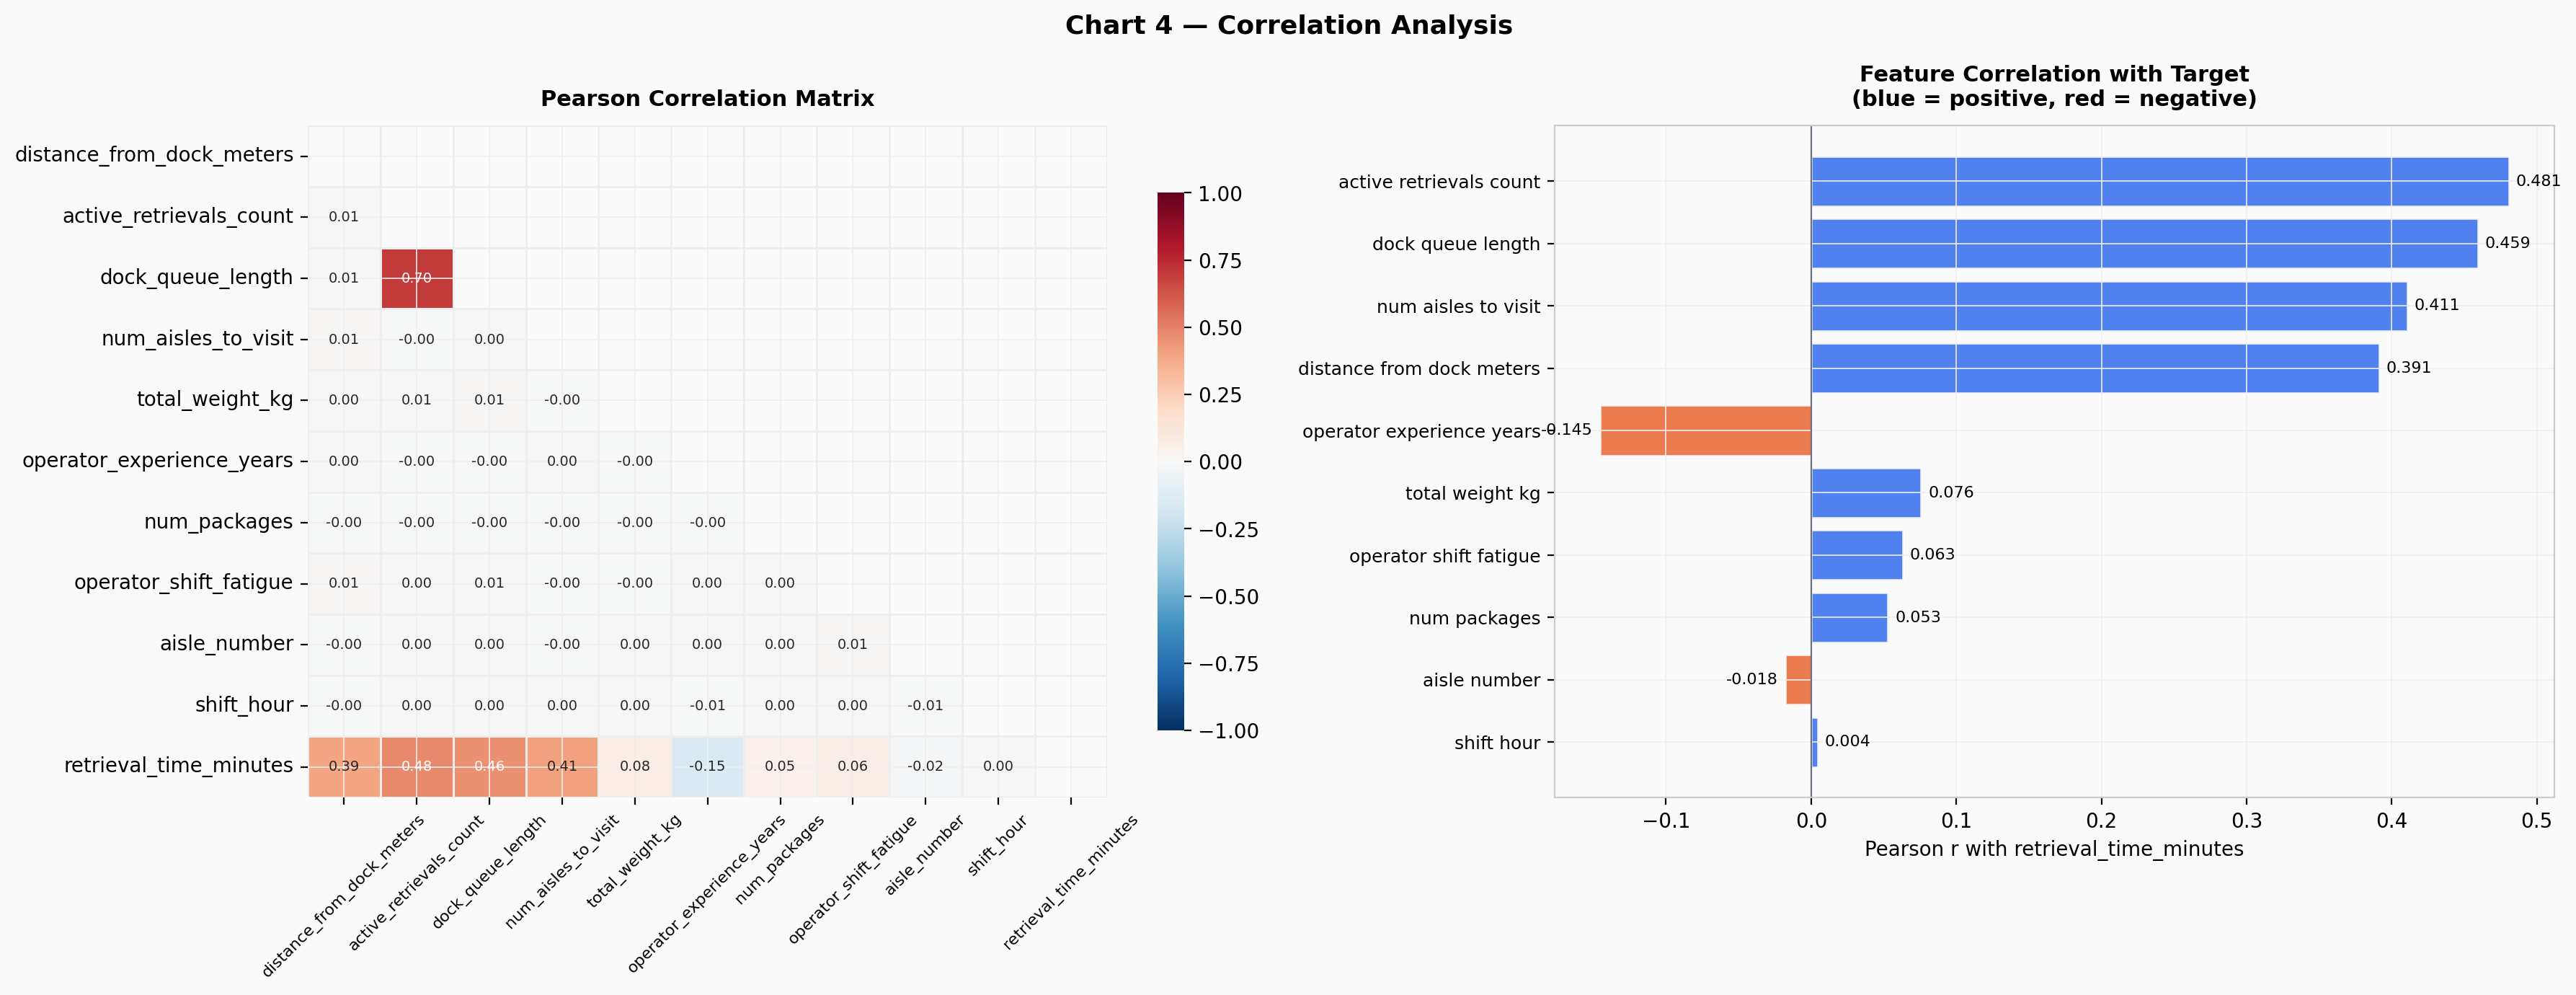

In [57]:
num_cols = ["distance_from_dock_meters","active_retrievals_count","dock_queue_length",
            "num_aisles_to_visit","total_weight_kg","operator_experience_years",
            "num_packages","operator_shift_fatigue","aisle_number","shift_hour",TARGET]

corr_mat = df[num_cols].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Chart 4 — Correlation Analysis", fontsize=13, fontweight="bold")

sns.heatmap(corr_mat, mask=mask, ax=axes[0], cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", linewidths=0.4, linecolor="#EEEEEE",
            annot_kws={"size":7}, vmin=-1, vmax=1, cbar_kws={"shrink":0.8})
axes[0].set_title("Pearson Correlation Matrix")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)

corr_target = corr_mat[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)
bar_colors  = [BLUE if v > 0 else CORAL for v in corr_target.values]
axes[1].barh(range(len(corr_target)), corr_target.values,
             color=bar_colors, alpha=0.8, edgecolor="white")
axes[1].set_yticks(range(len(corr_target)))
axes[1].set_yticklabels([c.replace("_"," ") for c in corr_target.index], fontsize=9)
axes[1].axvline(0, color=GRAY, linewidth=0.8)
axes[1].set_xlabel("Pearson r with retrieval_time_minutes")
axes[1].set_title("Feature Correlation with Target\n(blue = positive, red = negative)")
for i, v in enumerate(corr_target.values):
    axes[1].text(v+(0.005 if v>=0 else -0.005), i, f"{v:.3f}",
                 va="center", ha="left" if v>=0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

### 3.6 Chart 5 — Interaction Effects
> Hidden combinations that create nonlinear delays — the most important patterns for ML to learn.

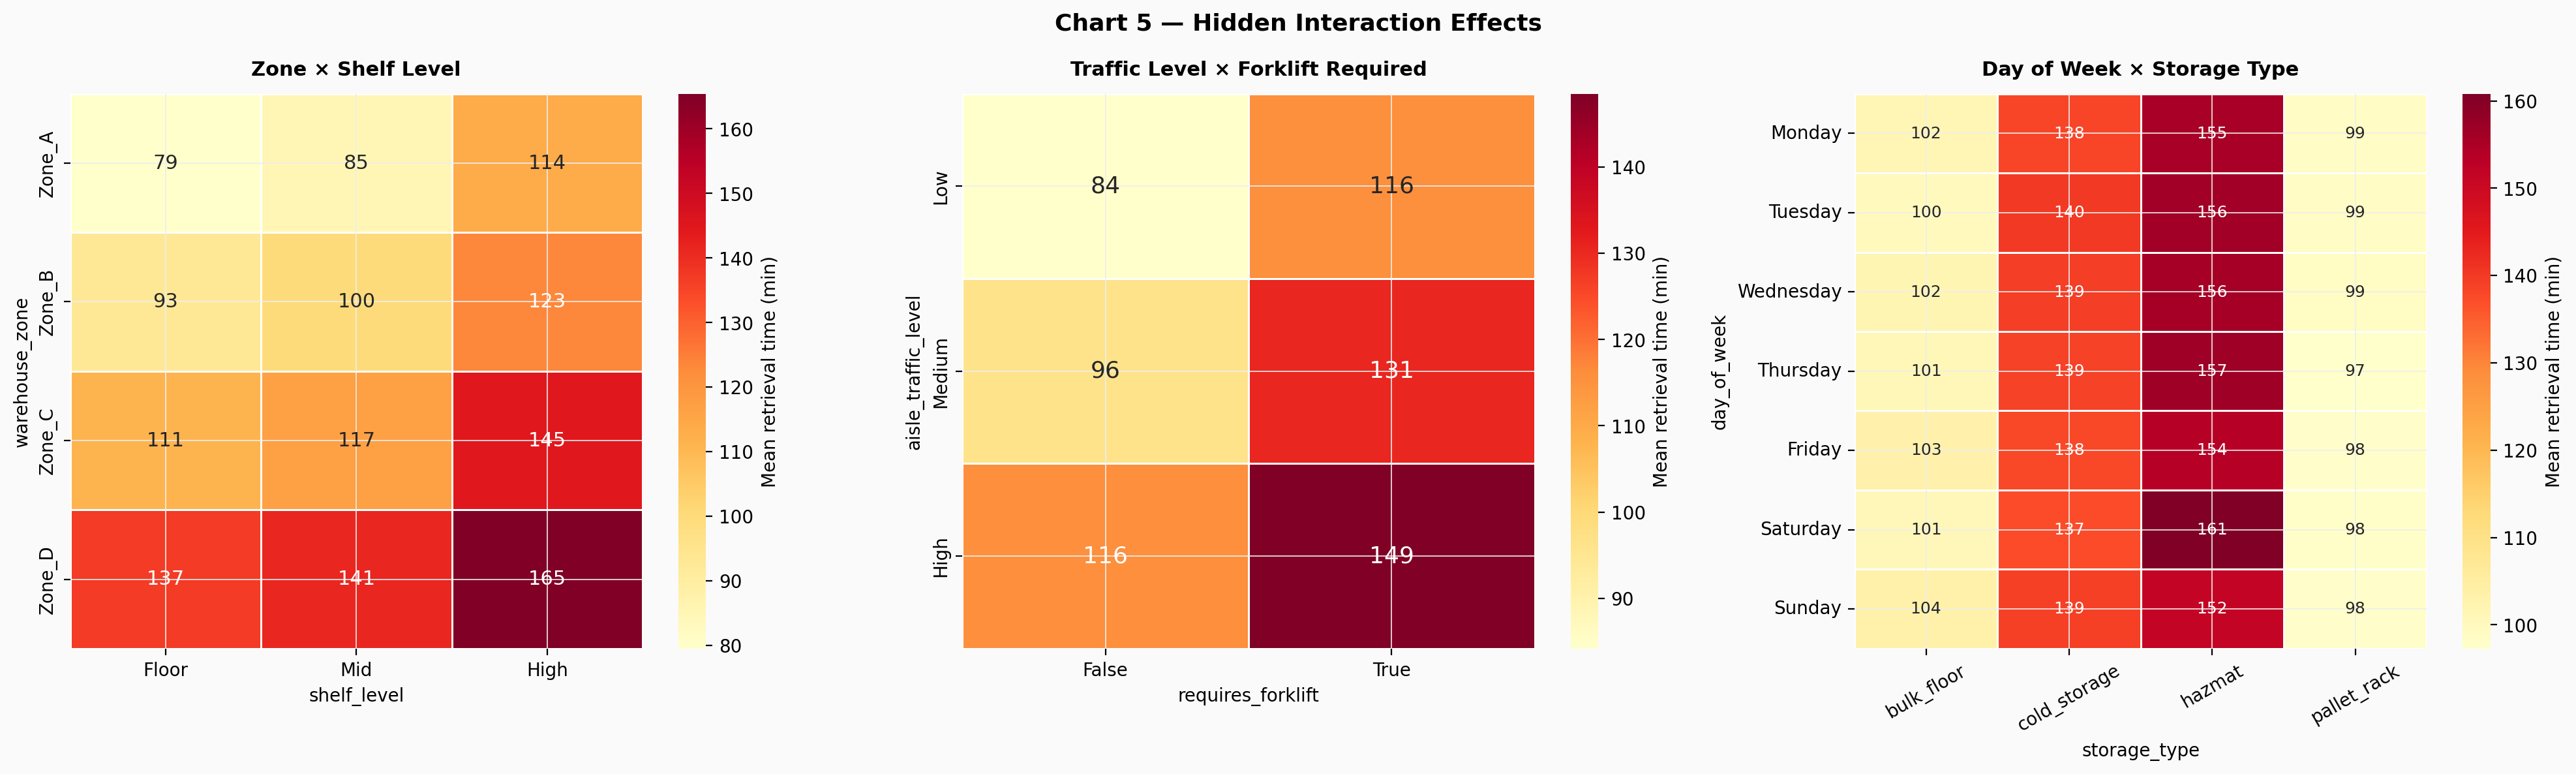

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Chart 5 — Hidden Interaction Effects", fontsize=13, fontweight="bold")

pivot1 = (df.groupby(["warehouse_zone","shelf_level"])[TARGET].mean().unstack()
            .reindex(["Zone_A","Zone_B","Zone_C","Zone_D"])[["Floor","Mid","High"]])
sns.heatmap(pivot1, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", annot_kws={"size":11},
            cbar_kws={"label":"Mean retrieval time (min)"})
axes[0].set_title("Zone × Shelf Level")

pivot2 = (df.groupby(["aisle_traffic_level","requires_forklift"])[TARGET].mean().unstack()
            .reindex(["Low","Medium","High"]))
sns.heatmap(pivot2, ax=axes[1], cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", annot_kws={"size":13},
            cbar_kws={"label":"Mean retrieval time (min)"})
axes[1].set_title("Traffic Level × Forklift Required")

pivot3 = (df.groupby(["day_of_week","storage_type"])[TARGET].mean().unstack()
            .reindex(dow_order))
sns.heatmap(pivot3, ax=axes[2], cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", annot_kws={"size":9},
            cbar_kws={"label":"Mean retrieval time (min)"})
axes[2].set_title("Day of Week × Storage Type")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 3.7 Chart 6 — Key Feature Distributions
> Understand shape and spread of important individual features.

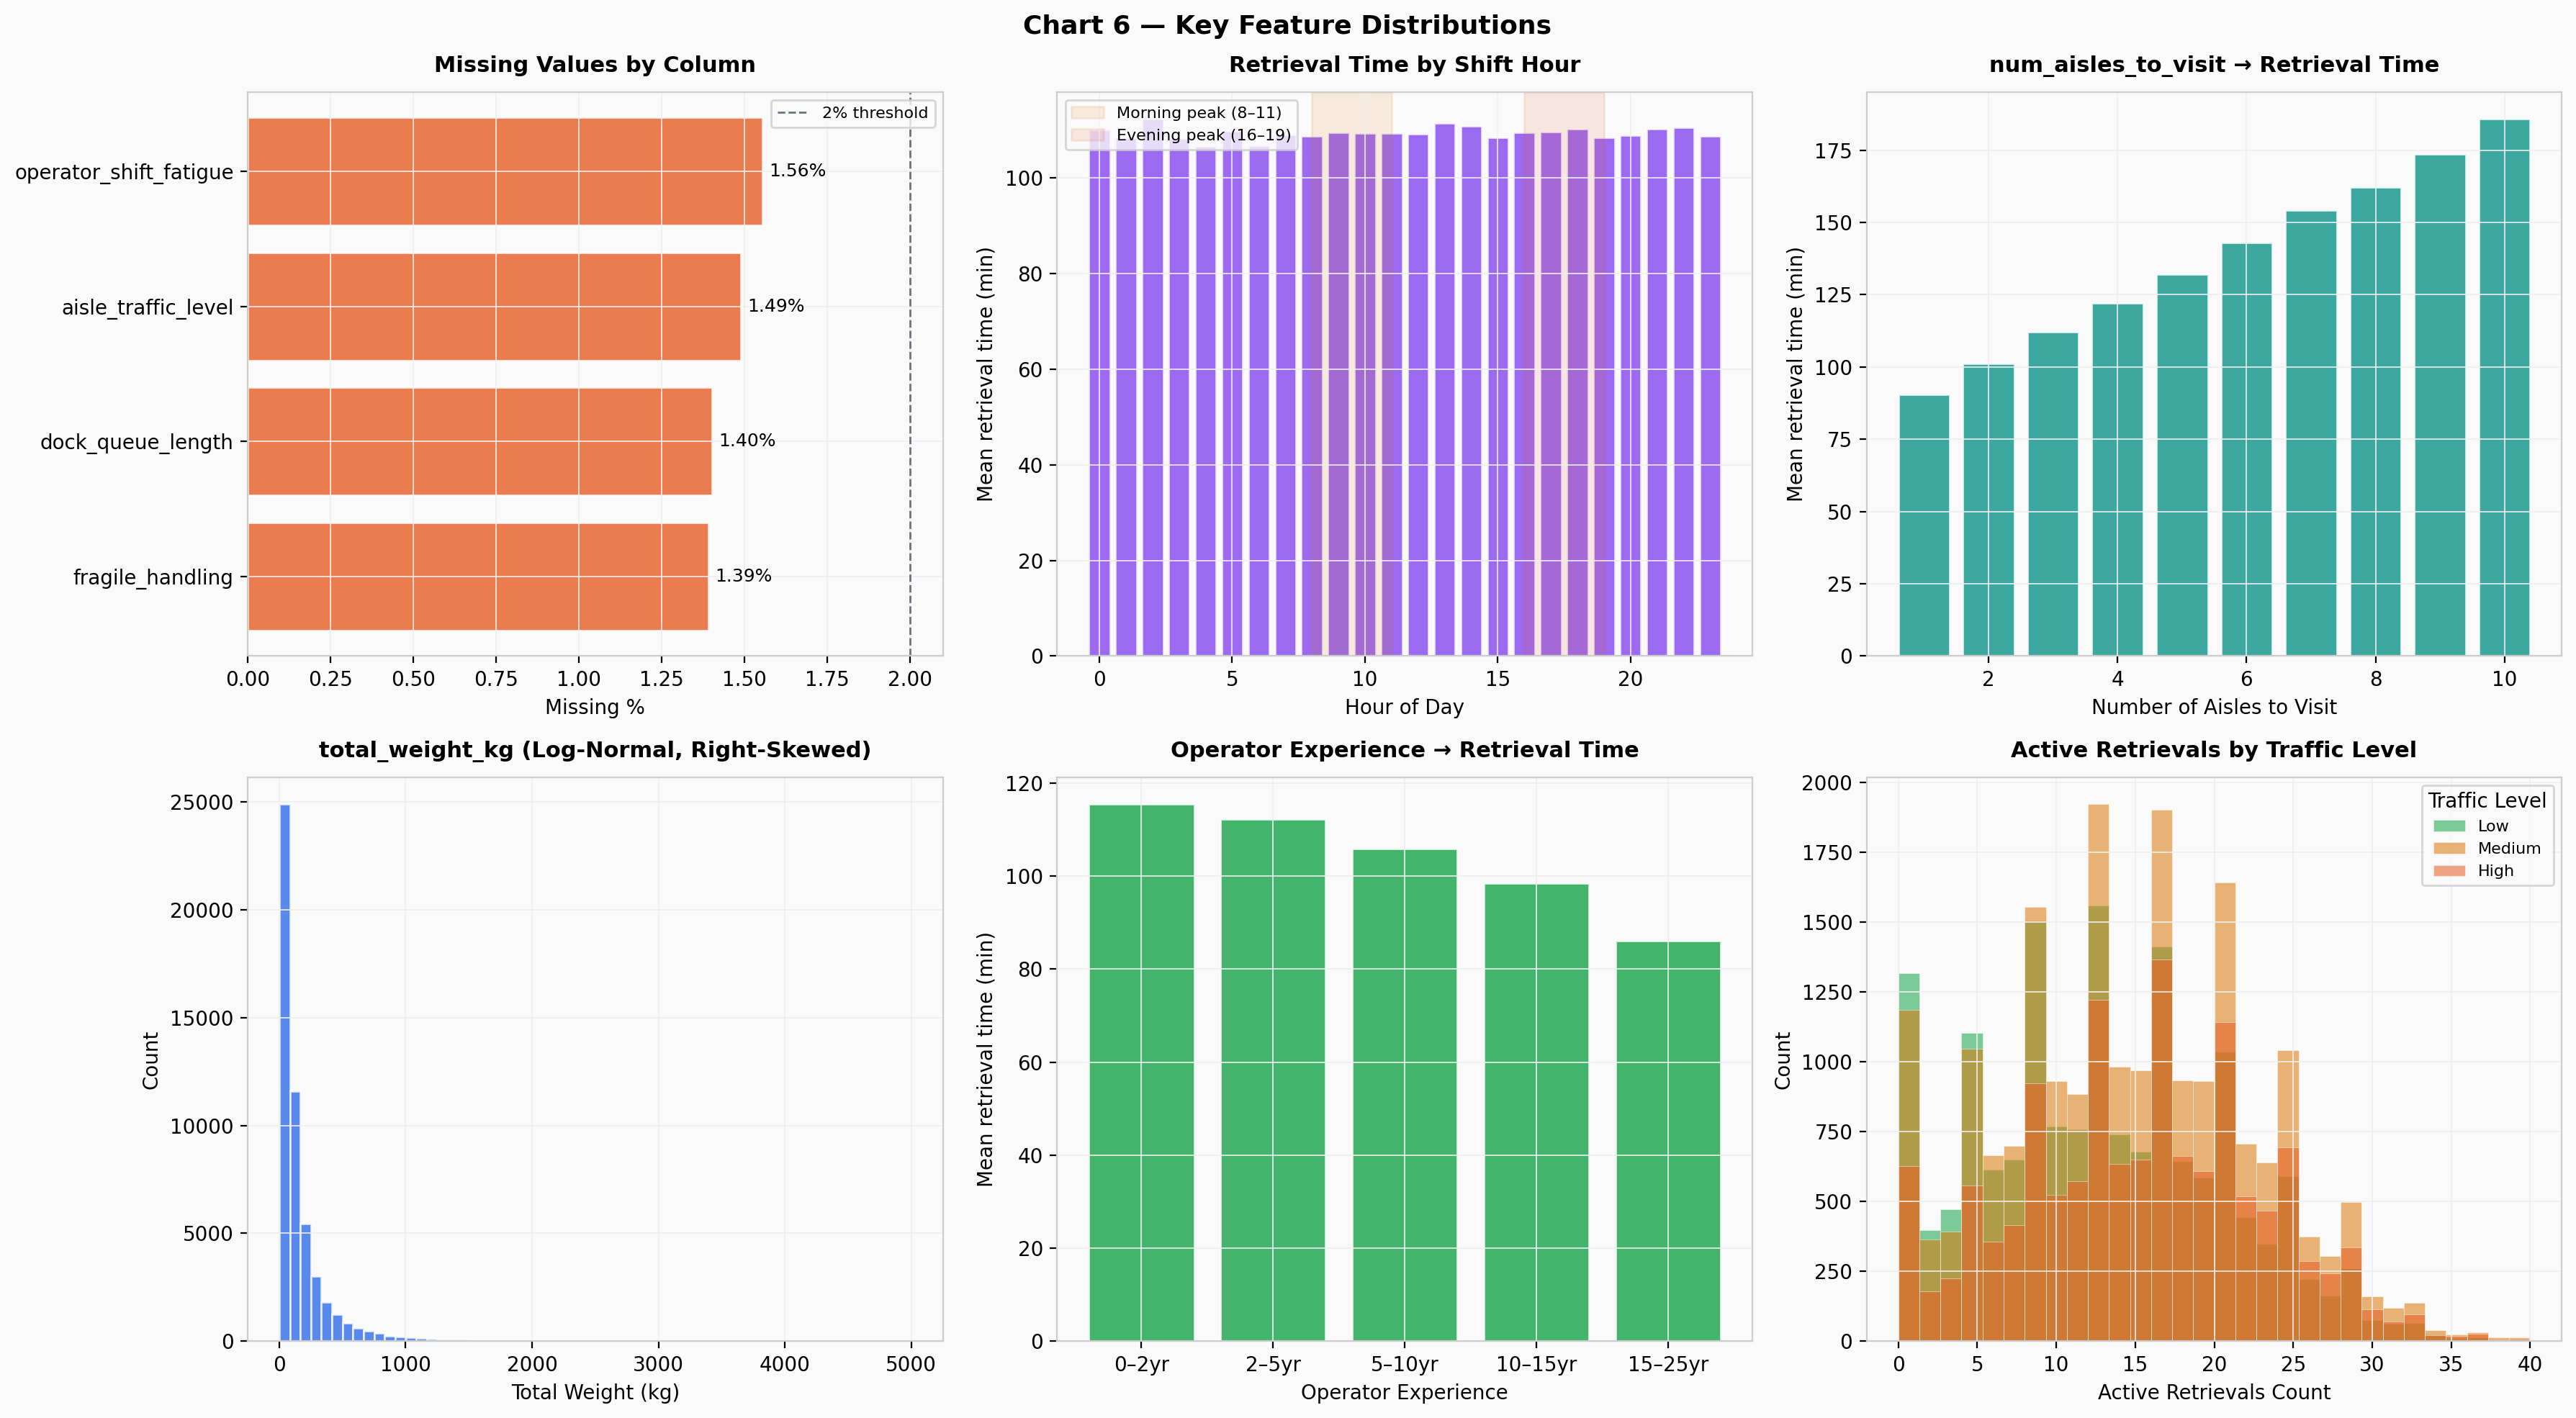

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Chart 6 — Key Feature Distributions", fontsize=13, fontweight="bold")

# Missing values
ax   = axes[0,0]
miss = (df.isnull().mean()*100)
miss = miss[miss > 0].sort_values(ascending=True)
ax.barh(miss.index, miss.values, color=CORAL, alpha=0.8, edgecolor="white")
ax.axvline(2, color=GRAY, linestyle="--", linewidth=1, label="2% threshold")
ax.set_xlabel("Missing %"); ax.set_title("Missing Values by Column")
ax.legend(fontsize=8)
for i, v in enumerate(miss.values):
    ax.text(v+0.02, i, f"{v:.2f}%", va="center", fontsize=9)

# Shift hour
ax       = axes[0,1]
hr_means = df.groupby("shift_hour")[TARGET].mean()
ax.bar(hr_means.index, hr_means.values, color=PURPLE, alpha=0.75, edgecolor="white")
ax.axvspan(8,  11, alpha=0.12, color=AMBER, label="Morning peak (8–11)")
ax.axvspan(16, 19, alpha=0.12, color=CORAL, label="Evening peak (16–19)")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Mean retrieval time (min)")
ax.set_title("Retrieval Time by Shift Hour"); ax.legend(fontsize=8)

# Num aisles
ax   = axes[0,2]
nais = df.groupby("num_aisles_to_visit")[TARGET].mean()
ax.bar(nais.index, nais.values, color=TEAL, alpha=0.8, edgecolor="white")
ax.set_xlabel("Number of Aisles to Visit")
ax.set_ylabel("Mean retrieval time (min)")
ax.set_title("num_aisles_to_visit → Retrieval Time")

# Weight distribution
ax = axes[1,0]
ax.hist(df["total_weight_kg"], bins=60, color=BLUE, alpha=0.75, edgecolor="white")
ax.set_xlabel("Total Weight (kg)"); ax.set_ylabel("Count")
ax.set_title("total_weight_kg (Log-Normal, Right-Skewed)")

# Operator experience
ax      = axes[1,1]
exp_bin = pd.cut(df["operator_experience_years"], bins=[0,2,5,10,15,25],
                 labels=["0–2yr","2–5yr","5–10yr","10–15yr","15–25yr"])
exp_means = df.groupby(exp_bin, observed=True)[TARGET].mean()
ax.bar(exp_means.index, exp_means.values, color=GREEN, alpha=0.8, edgecolor="white")
ax.set_xlabel("Operator Experience"); ax.set_ylabel("Mean retrieval time (min)")
ax.set_title("Operator Experience → Retrieval Time")

# Active retrievals by traffic level
ax = axes[1,2]
for lvl, color in zip(["Low","Medium","High"], [GREEN, AMBER, CORAL]):
    sub = df[df["aisle_traffic_level"]==lvl]["active_retrievals_count"].dropna()
    ax.hist(sub, bins=30, alpha=0.55, color=color,
            label=lvl, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Active Retrievals Count"); ax.set_ylabel("Count")
ax.set_title("Active Retrievals by Traffic Level")
ax.legend(title="Traffic Level", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering
### 4.1 Handle Missing Values

In [60]:
print("Before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in ["dock_queue_length","operator_shift_fatigue"]:
    df[col].fillna(df[col].median(), inplace=True)

for col in ["aisle_traffic_level","fragile_handling"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAfter:")
total = df.isnull().sum().sum()
print("Total missing values:", total)
print("✅ Clean!" if total == 0 else "⚠️ Still has missing values")

Before:
dock_queue_length         729
aisle_traffic_level       775
fragile_handling          724
operator_shift_fatigue    809
dtype: int64

After:
Total missing values: 0
✅ Clean!


### 4.2 Fix Data Types
> requires_forklift and fragile_handling are stored as string 'True'/'False' — convert to 0/1

In [61]:
for col in ["requires_forklift","fragile_handling"]:
    df[col] = df[col].map({"True":1,"False":0,True:1,False:0}).astype(float)

print("Fixed dtypes:")
print(df[["requires_forklift","fragile_handling"]].dtypes)
df[["requires_forklift","fragile_handling"]].head()

Fixed dtypes:
requires_forklift    float64
fragile_handling     float64
dtype: object


,requires_forklift,fragile_handling
0,0.0,1.0
1,1.0,0.0
2,0.0,0.0
3,1.0,0.0
4,1.0,1.0


### 4.3 Feature Engineering
> Create new features from existing ones to help the model learn patterns faster.

In [62]:
# Peak hour flag
df["is_peak_hour"] = df["shift_hour"].apply(
    lambda h: 1 if (8<=h<=11 or 16<=h<=19) else 0)

# Day flags
df["is_monday"]  = (df["day_of_week"] == "Monday").astype(int)
df["is_weekend"] = df["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

# Busy aisle flag
busy_aisles      = {5, 10, 15, 20, 25, 30}
df["is_busy_aisle"] = df["aisle_number"].apply(
    lambda x: 1 if x in busy_aisles else 0)

# Total congestion score
traffic_map          = {"Low":0, "Medium":1, "High":2}
df["congestion_score"] = (
    df["active_retrievals_count"] * 0.5 +
    df["dock_queue_length"]        * 0.3 +
    df["aisle_traffic_level"].map(traffic_map) * 5
)

# Heavy cargo without forklift (severe delay scenario)
df["heavy_no_forklift"] = (
    (df["total_weight_kg"] > 600) & (df["requires_forklift"] == 0)
).astype(int)

# Complexity score
df["complexity_score"] = (
    df["num_aisles_to_visit"] * 2 +
    df["num_packages"]        * 0.05 +
    df["requires_forklift"]   * 3 +
    df["fragile_handling"]    * 2
)

# Log weight (reduces skewness)
df["log_weight"] = np.log1p(df["total_weight_kg"])

new_feats = ["is_peak_hour","is_monday","is_weekend","is_busy_aisle",
             "congestion_score","heavy_no_forklift","complexity_score","log_weight"]
print("New features created ✅")
df[new_feats].describe().round(2)

New features created ✅


,is_peak_hour,is_monday,is_weekend,is_busy_aisle,congestion_score,heavy_no_forklift,complexity_score,log_weight
count,52000.00,52000.0,52000.00,52000.00,52000.00,52000.00,52000.00,52000.00
mean,0.53,0.2,0.15,0.12,13.99,0.01,7.93,4.52
std,0.50,0.4,0.36,0.32,6.75,0.12,4.49,1.18
min,0.00,0.0,0.00,0.00,0.00,0.00,2.05,0.69
25%,0.00,0.0,0.00,0.00,9.10,0.00,4.60,3.72
50%,1.00,0.0,0.00,0.00,13.90,0.00,7.05,4.51
75%,1.00,0.0,0.00,0.00,18.80,0.00,10.25,5.30
max,1.00,1.0,1.00,1.00,37.50,1.00,27.90,8.52


### 4.4 Encode Categorical Features
> ML models need numbers — convert all text categories to numeric values.

In [63]:
# Ordinal encoding (has meaningful order)
df["shelf_level_enc"]    = df["shelf_level"].map({"Floor":0,"Mid":1,"High":2})
df["aisle_traffic_enc"]  = df["aisle_traffic_level"].map({"Low":0,"Medium":1,"High":2})
df["warehouse_zone_enc"] = df["warehouse_zone"].map(
    {"Zone_A":0,"Zone_B":1,"Zone_C":2,"Zone_D":3})

# One-hot encoding (no meaningful order)
df = pd.get_dummies(df, columns=["storage_type","special_equipment_needed",
                                  "day_of_week"], drop_first=False)

print("Shape after encoding:", df.shape)

Shape after encoding: (52000, 43)


In [64]:
df

,request_date,request_timestamp,warehouse_zone,aisle_number,shelf_level,distance_from_dock_meters,active_retrievals_count,dock_queue_length,aisle_traffic_level,shift_hour,...,special_equipment_needed_cold_gear,special_equipment_needed_hazmat_suit,special_equipment_needed_none,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2025-06-17,2025-06-17 08:57:32,Zone_C,10,Mid,321.0,16,6.0,High,8,...,False,False,True,False,False,False,False,False,True,False
1,2025-07-21,2025-07-21 20:50:49,Zone_C,34,Mid,230.3,16,7.0,Medium,20,...,False,False,True,False,True,False,False,False,False,False
2,2025-10-03,2025-10-03 21:52:15,Zone_A,19,Mid,18.3,9,5.0,Medium,21,...,False,False,True,True,False,False,False,False,False,False
3,2025-09-17,2025-09-17 18:31:18,Zone_A,16,Floor,42.5,25,19.0,High,18,...,True,False,False,False,False,False,False,False,False,True
4,2025-11-10,2025-11-10 21:34:27,Zone_A,47,Floor,14.1,21,7.0,Low,21,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,2025-01-24,2025-01-24 19:01:35,Zone_B,11,High,193.0,8,5.0,Medium,19,...,False,False,True,True,False,False,False,False,False,False
51996,2025-01-21,2025-01-21 00:39:19,Zone_C,42,Mid,199.7,25,6.0,Low,0,...,True,False,False,False,False,False,False,False,True,False
51997,2025-06-12,2025-06-12 09:53:29,Zone_D,47,Floor,374.8,21,4.0,Low,9,...,False,False,True,False,False,False,False,True,False,False
51998,2025-11-12,2025-11-12 15:43:14,Zone_C,44,Floor,282.7,19,11.0,Medium,15,...,True,False,False,False,False,False,False,False,False,True


### 4.5 Final Feature Selection & Train/Test Split

In [65]:
df['request_date'] = pd.to_datetime(df['request_date'], errors='coerce')
df['request_timestamp'] = pd.to_datetime(df['request_timestamp'], errors='coerce')

In [66]:
drop_cols = ["warehouse_zone","shelf_level","aisle_traffic_level",
             "day_of_week","total_weight_kg"]

FEATURES = [c for c in df.columns if c not in drop_cols + [TARGET]]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Features : {len(FEATURES)}")
print(f"Train    : {X_train.shape}")
print(f"Test     : {X_test.shape}")

Features : 38
Train    : (41600, 38)
Test     : (10400, 38)


## 5. Baseline Model Comparison
> Train 4 models with default settings first to see which one performs best before tuning.

In [67]:
def preprocess_datetime_features(df):
    df = df.copy()
    ts = pd.to_datetime(df['request_timestamp'])
    dt = pd.to_datetime(df['request_date'])
    
    df['request_hour'] = ts.dt.hour
    df['request_dayofweek'] = ts.dt.dayofweek  # 0=Mon, 6=Sun
    df['request_month'] = dt.dt.month
    df['request_is_weekend'] = (ts.dt.dayofweek >= 5).astype(int)
    
    return df.drop(columns=['request_date', 'request_timestamp'])

X_train = preprocess_datetime_features(X_train)
X_test = preprocess_datetime_features(X_test)

In [68]:
FEATURES = X_train.columns.tolist()

joblib.dump(FEATURES, "cargo_retrieval_features.pkl")

['cargo_retrieval_features.pkl']

In [69]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest"    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost"          : XGBRegressor(n_estimators=200, random_state=42, verbosity=0, n_jobs=-1),
    "LightGBM"         : LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1),
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    y_pred  = model.predict(X_test)
    results[name] = {
        "MAE"    : mean_absolute_error(y_test, y_pred),
        "RMSE"   : np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2"     : r2_score(y_test, y_pred),
        "Time(s)": round(elapsed, 1)
    }
    print(f"{name:<22} | MAE={results[name]['MAE']:6.2f} | "
          f"RMSE={results[name]['RMSE']:6.2f} | "
          f"R²={results[name]['R2']:.4f} | "
          f"Time={results[name]['Time(s)']}s")

Linear Regression      | MAE= 15.14 | RMSE= 20.10 | R²=0.8495 | Time=0.1s
Random Forest          | MAE= 14.09 | RMSE= 18.89 | R²=0.8671 | Time=19.4s
XGBoost                | MAE= 13.27 | RMSE= 17.91 | R²=0.8805 | Time=1.1s
LightGBM               | MAE= 12.63 | RMSE= 16.86 | R²=0.8941 | Time=1.3s


### 5.1 Chart 7 — Baseline Model Comparison

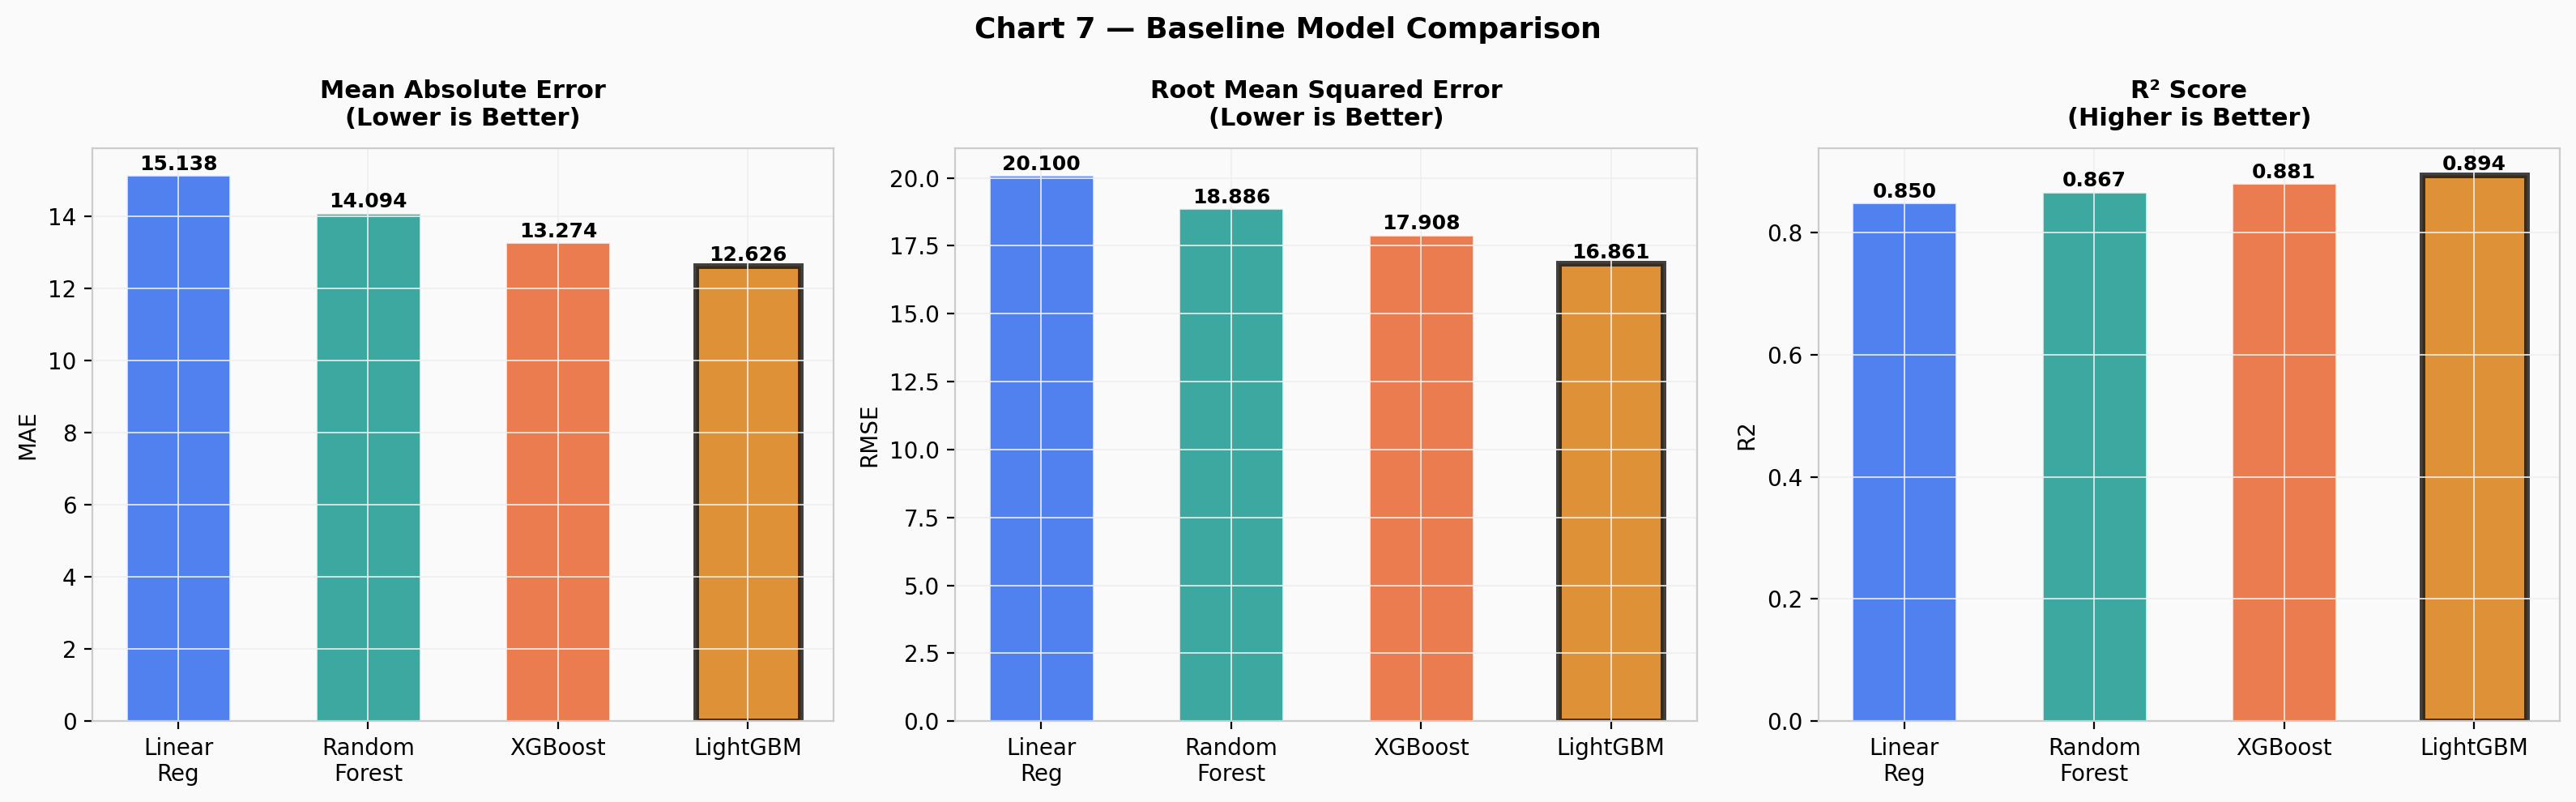

★ Best model is outlined in black


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 7 — Baseline Model Comparison", fontsize=13, fontweight="bold")

model_names = list(results.keys())
short_names = ["Linear\nReg","Random\nForest","XGBoost","LightGBM"]
bar_colors  = [BLUE, TEAL, CORAL, AMBER]
metrics     = [("MAE","Mean Absolute Error\n(Lower is Better)", False),
               ("RMSE","Root Mean Squared Error\n(Lower is Better)", False),
               ("R2","R² Score\n(Higher is Better)", True)]

for ax, (metric, ylabel, higher_better) in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    best = max(vals) if higher_better else min(vals)
    bars = ax.bar(short_names, vals, color=bar_colors, alpha=0.8,
                  edgecolor="white", width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002*max(vals),
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
        if v == best:
            bar.set_edgecolor("#111111"); bar.set_linewidth(2.5)
    ax.set_title(ylabel); ax.set_ylabel(metric)

plt.tight_layout()
plt.show()
print("★ Best model is outlined in black")

## 6. Hyperparameter Tuning
> Take the top 2 models and search for the best settings using RandomizedSearchCV (40 combos × 5-fold CV).
### 6.1 Tune XGBoost

In [72]:
xgb_params = {
    "n_estimators"     : [200, 300, 400, 500],
    "max_depth"        : [4, 5, 6, 7, 8],
    "learning_rate"    : [0.01, 0.05, 0.1, 0.15, 0.2],
    "subsample"        : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight" : [1, 3, 5, 7],
    "gamma"            : [0, 0.1, 0.2, 0.3],
    "reg_alpha"        : [0, 0.01, 0.1, 1],
    "reg_lambda"       : [0.5, 1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions = xgb_params,
    n_iter=40, cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=-1, verbose=1
)

xgb_search.fit(X_train, y_train)

print("\n✅ Best XGBoost Parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"   {k:<22}: {v}")
print(f"\nBest CV RMSE: {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best XGBoost Parameters:
   subsample             : 1.0
   reg_lambda            : 1.5
   reg_alpha             : 0
   n_estimators          : 500
   min_child_weight      : 3
   max_depth             : 4
   learning_rate         : 0.05
   gamma                 : 0.3
   colsample_bytree      : 0.7

Best CV RMSE: 16.9657


### 6.3 Tuned vs Baseline — Full Comparison Table

In [74]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# 1. Base model
lgbm_base = lgb.LGBMRegressor(random_state=42, verbose=-1)

# 2. Parameter space
param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [10, 20, 30]
}

# 3. Create & fit search object
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=20,          # Number of random combinations to try
    cv=3,               # Cross-validation folds
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
lgbm_search.fit(X_train, y_train)
print("✅ LightGBM tuning complete. Re-run your comparison cell now.")

✅ LightGBM tuning complete. Re-run your comparison cell now.


In [76]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 🔍 Safety checks for missing search objects
if 'xgb_search' not in locals():
    raise RuntimeError("⚠️ `xgb_search` not found. Run your XGBoost GridSearch/RandomizedSearch cell first.")
if 'lgbm_search' not in locals():
    raise RuntimeError("⚠️ `lgbm_search` not found. Run your LightGBM tuning cell first.")

# ✅ Extract best estimators
best_xgb  = xgb_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

# 📊 Evaluate tuned models
tuned_results = {}
for name, model in [("XGBoost (Tuned)", best_xgb),
                    ("LightGBM (Tuned)", best_lgbm)]:
    y_pred = model.predict(X_test)
    tuned_results[name] = {
        "MAE" : mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2"  : r2_score(y_test, y_pred)
    }

# 🔄 Merge with baseline results (ensure `results` exists from earlier)
if 'results' not in locals():
    raise RuntimeError("⚠️ `results` dictionary not found. Run your baseline model evaluation cell first.")

all_results = {**results, **tuned_results}
compare_df  = pd.DataFrame(all_results).T[["MAE", "RMSE", "R2"]].round(4)

print("📈 Full Model Comparison:")
print(compare_df)

📈 Full Model Comparison:
                       MAE     RMSE      R2
Linear Regression  15.1381  20.1002  0.8495
Random Forest      14.0944  18.8858  0.8671
XGBoost            13.2738  17.9079  0.8805
LightGBM           12.6259  16.8612  0.8941
XGBoost (Tuned)    12.4654  16.6042  0.8973
LightGBM (Tuned)   12.4346  16.6054  0.8973


### 6.4 Chart 8 — Baseline vs Tuned Comparison

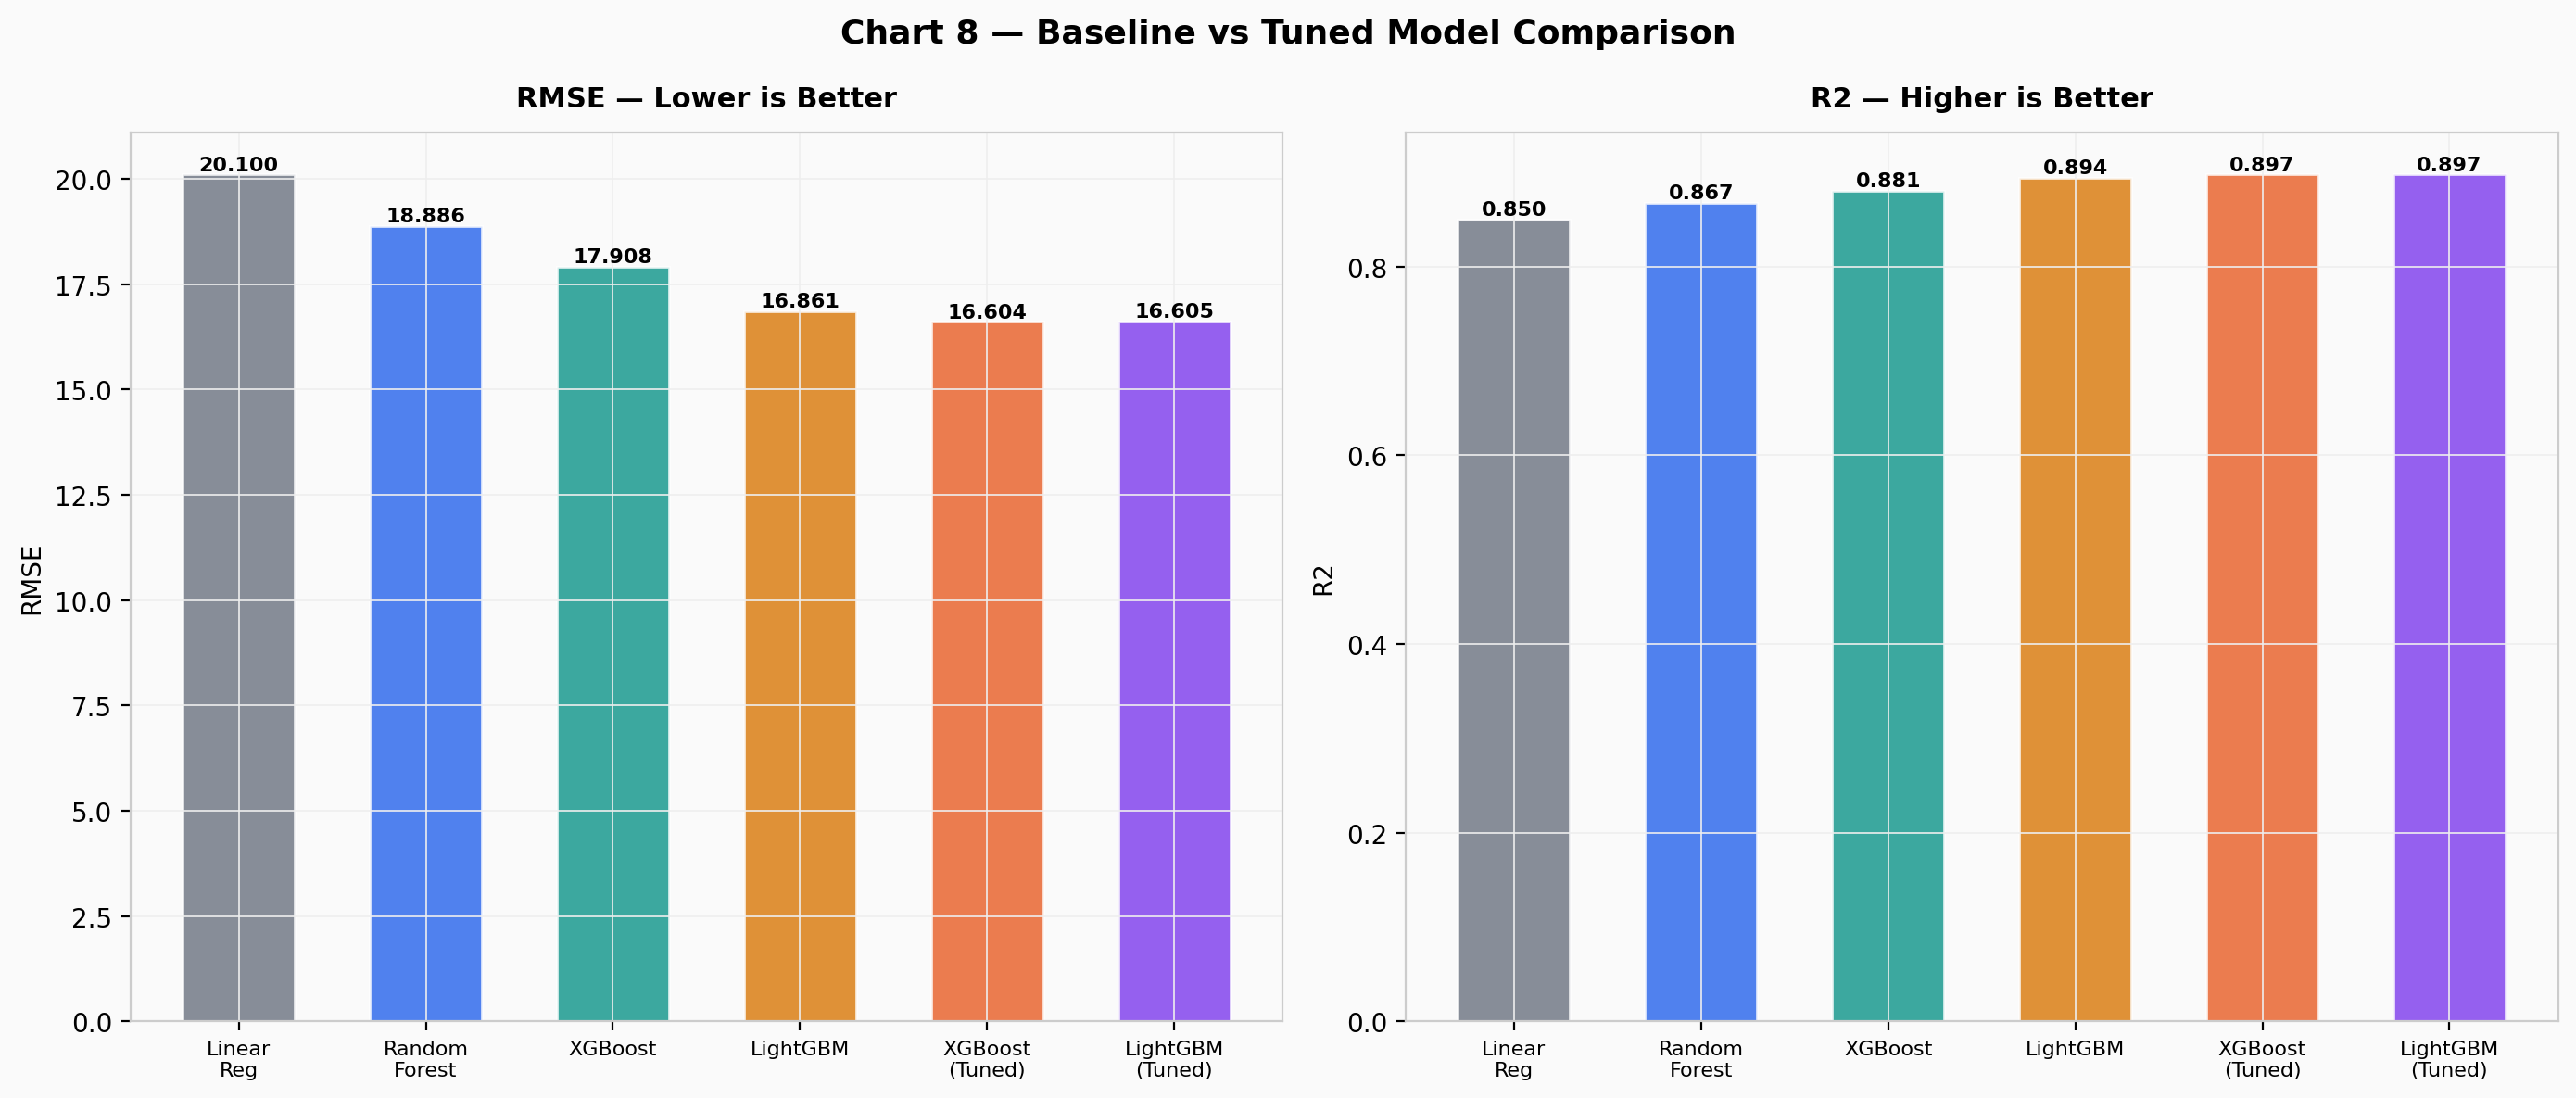

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chart 8 — Baseline vs Tuned Model Comparison",
             fontsize=13, fontweight="bold")

model_labels = list(all_results.keys())
short_labels = ["Linear\nReg","Random\nForest","XGBoost","LightGBM",
                "XGBoost\n(Tuned)","LightGBM\n(Tuned)"]
bar_colors   = [GRAY, BLUE, TEAL, AMBER, CORAL, PURPLE]

for ax, metric in zip(axes, ["RMSE","R2"]):
    vals = [all_results[m][metric] for m in model_labels]
    bars = ax.bar(short_labels, vals, color=bar_colors,
                  alpha=0.8, edgecolor="white", width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.001*max(vals),
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
    ax.set_title(f"{metric} — {'Higher is Better' if metric=='R2' else 'Lower is Better'}")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

## 7. Final Model Evaluation
### 7.1 Select Best Model

In [78]:
best_name  = min(all_results, key=lambda m: all_results[m]["RMSE"])
best_model = best_xgb if "XGBoost" in best_name else best_lgbm
y_pred     = best_model.predict(X_test)

print(f"🏆 Best Model : {best_name}")
print(f"   R²         : {all_results[best_name]['R2']:.4f}")
print(f"   RMSE       : {all_results[best_name]['RMSE']:.2f} min")
print(f"   MAE        : {all_results[best_name]['MAE']:.2f} min")

🏆 Best Model : XGBoost (Tuned)
   R²         : 0.8973
   RMSE       : 16.60 min
   MAE        : 12.47 min


### 7.2 Chart 9 — Actual vs Predicted
> A perfect model would have all points exactly on the diagonal line.

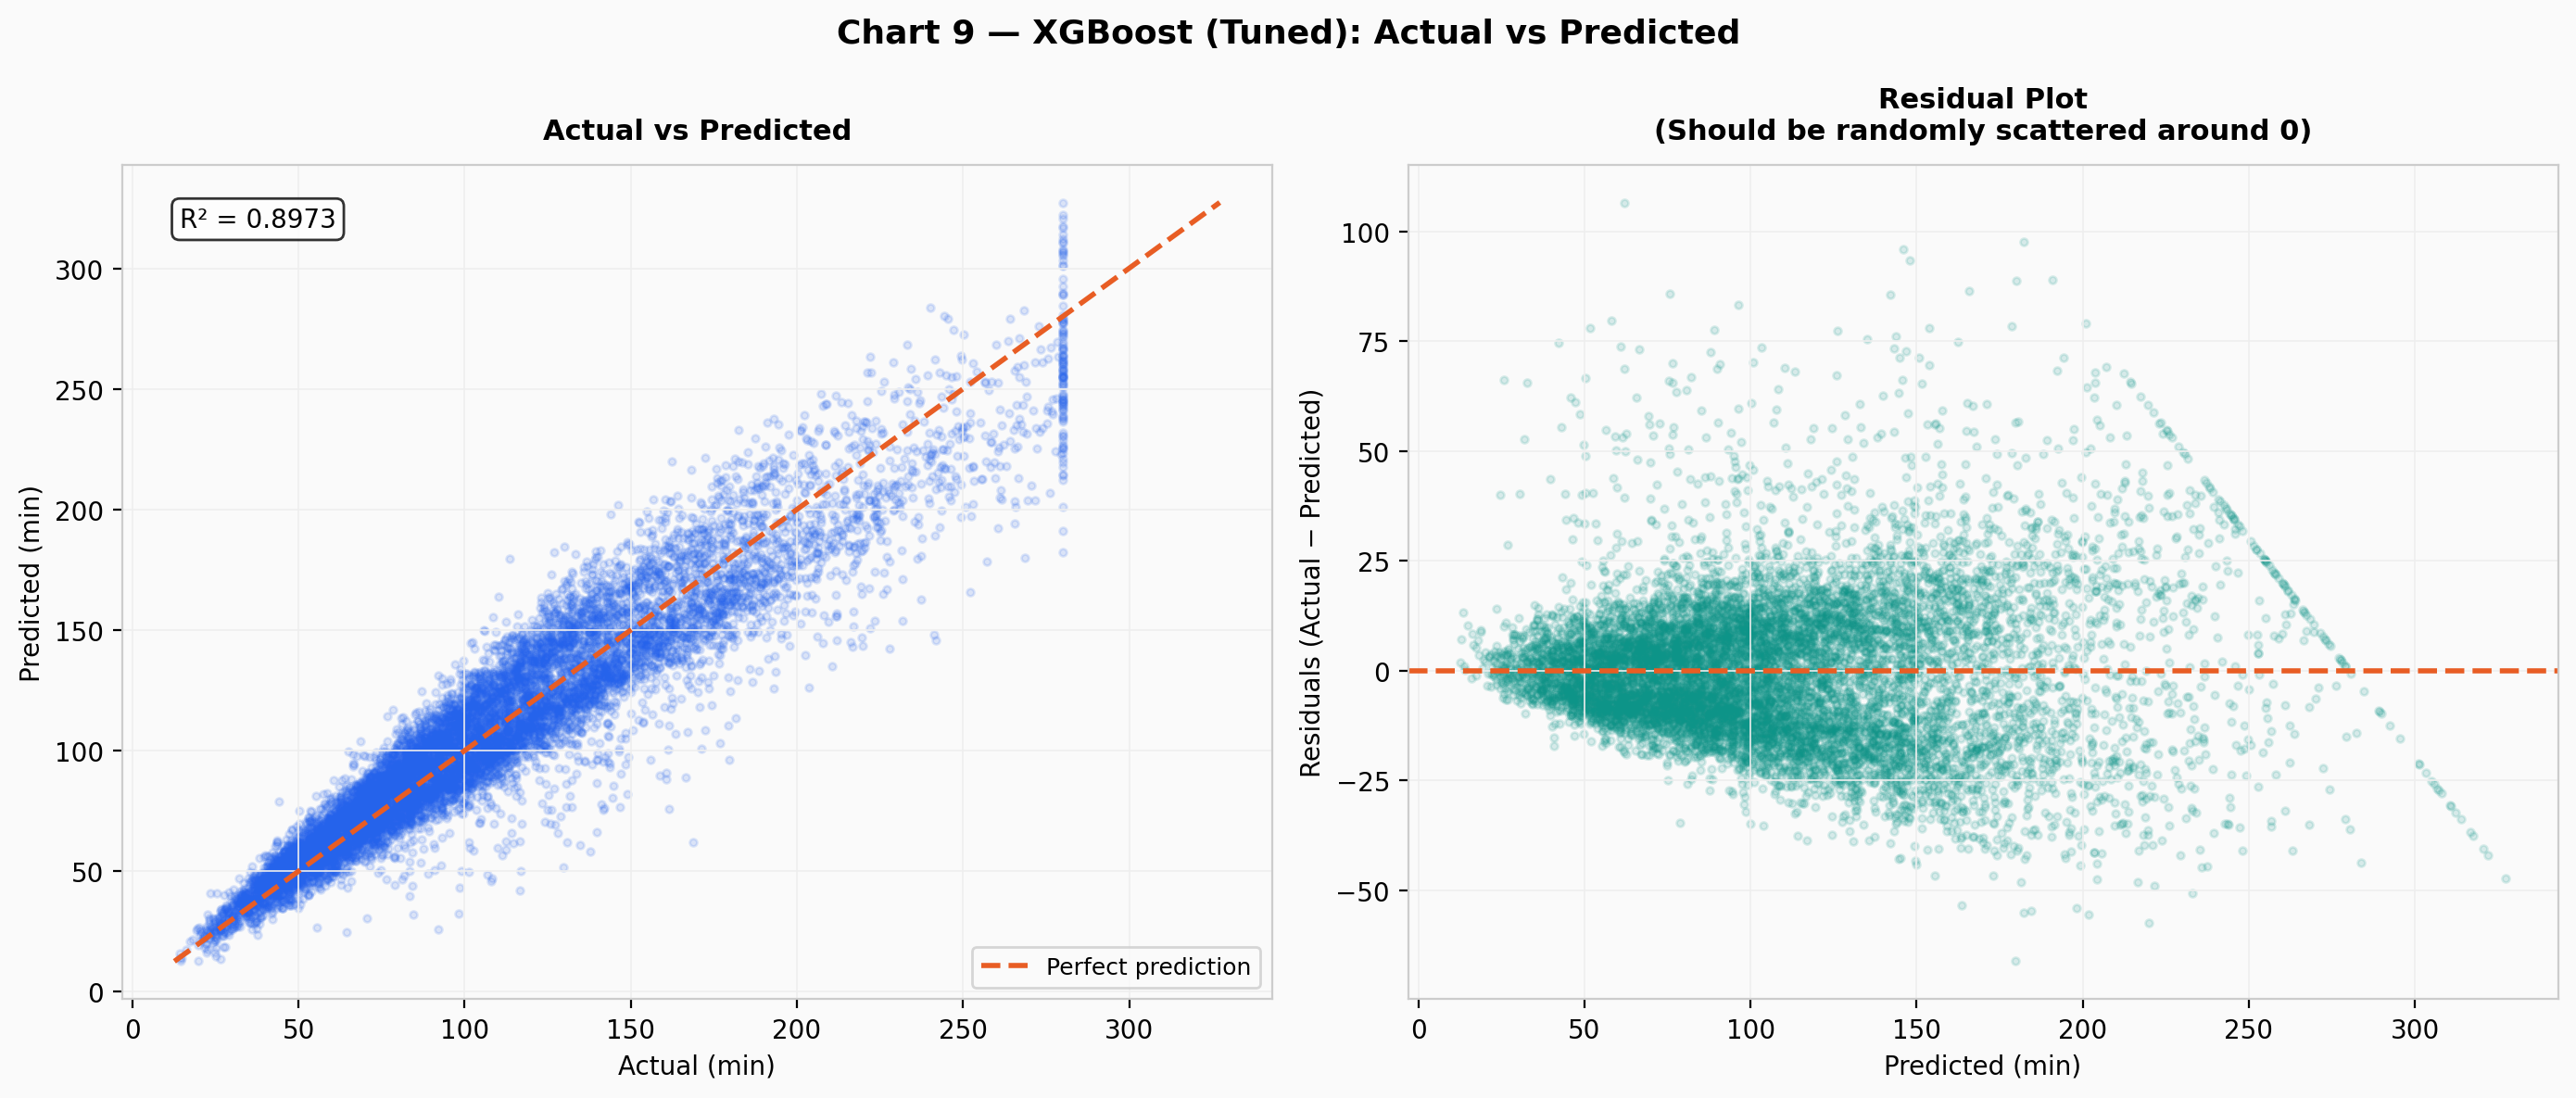

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Chart 9 — {best_name}: Actual vs Predicted",
             fontsize=13, fontweight="bold")

# Scatter
ax   = axes[0]
ax.scatter(y_test, y_pred, alpha=0.15, s=8, color=BLUE)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color=CORAL, linewidth=2, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual (min)"); ax.set_ylabel("Predicted (min)")
ax.set_title("Actual vs Predicted")
ax.legend(fontsize=9)
ax.text(0.05, 0.95, f"R² = {r2_score(y_test, y_pred):.4f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Residuals
ax        = axes[1]
residuals = y_test - y_pred
ax.scatter(y_pred, residuals, alpha=0.15, s=8, color=TEAL)
ax.axhline(0, color=CORAL, linewidth=2, linestyle="--")
ax.set_xlabel("Predicted (min)"); ax.set_ylabel("Residuals (Actual − Predicted)")
ax.set_title("Residual Plot\n(Should be randomly scattered around 0)")

plt.tight_layout()
plt.show()

### 7.3 Chart 10 — Feature Importance
> Which features does the model rely on most to make predictions?

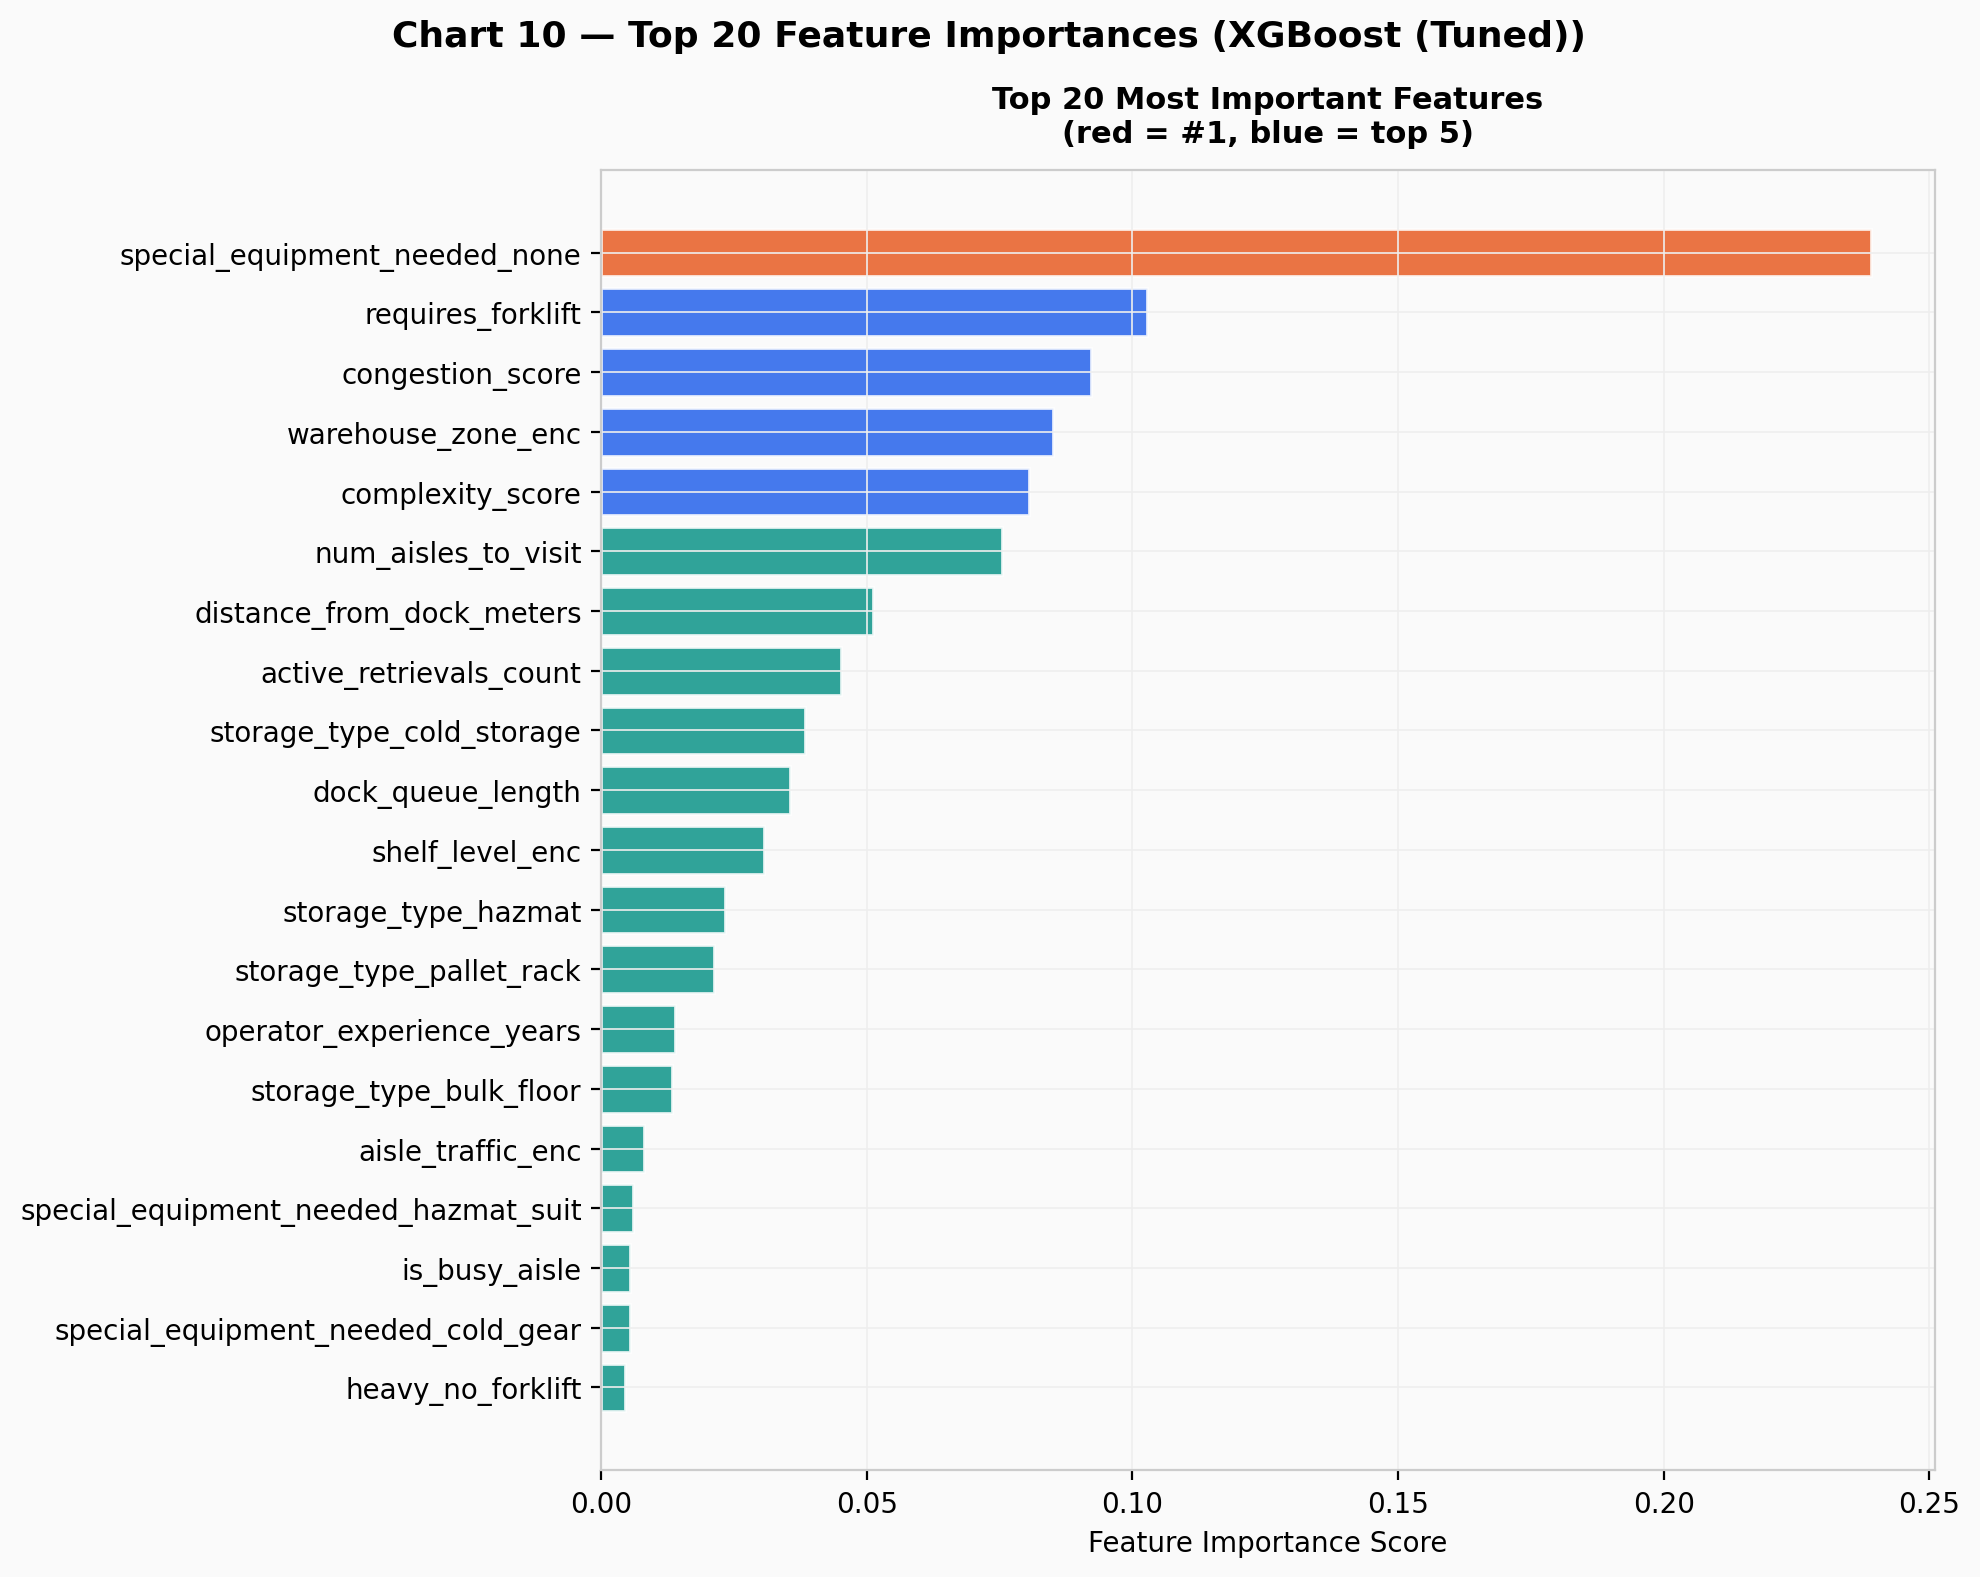

Top 10 Features:
                      Feature  Importance
special_equipment_needed_none    0.239029
            requires_forklift    0.102680
             congestion_score    0.092126
           warehouse_zone_enc    0.085081
             complexity_score    0.080592
          num_aisles_to_visit    0.075424
    distance_from_dock_meters    0.051223
      active_retrievals_count    0.045138
    storage_type_cold_storage    0.038385
            dock_queue_length    0.035631


In [80]:
feature_names = list(X_train.columns)

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(np.ravel(best_model.coef_))
else:
    raise AttributeError("best_model does not provide feature importances.")

if len(feature_names) != len(importances):
    raise ValueError(f"Feature count ({len(feature_names)}) does not match importance count ({len(importances)}).")

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f"Chart 10 — Top 20 Feature Importances ({best_name})",
             fontsize=13, fontweight="bold")

colors_feat = [CORAL if i==0 else BLUE if i<5 else TEAL
               for i in range(len(importance_df))]
ax.barh(importance_df["Feature"][::-1],
        importance_df["Importance"][::-1],
        color=colors_feat[::-1], alpha=0.85, edgecolor="white")
ax.set_xlabel("Feature Importance Score")
ax.set_title("Top 20 Most Important Features\n(red = #1, blue = top 5)")

plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(importance_df.head(10).to_string(index=False))

### 7.4 Chart 11 — Prediction Error Distribution
> How far off are our predictions? What % fall within 5, 10, 15 minutes?

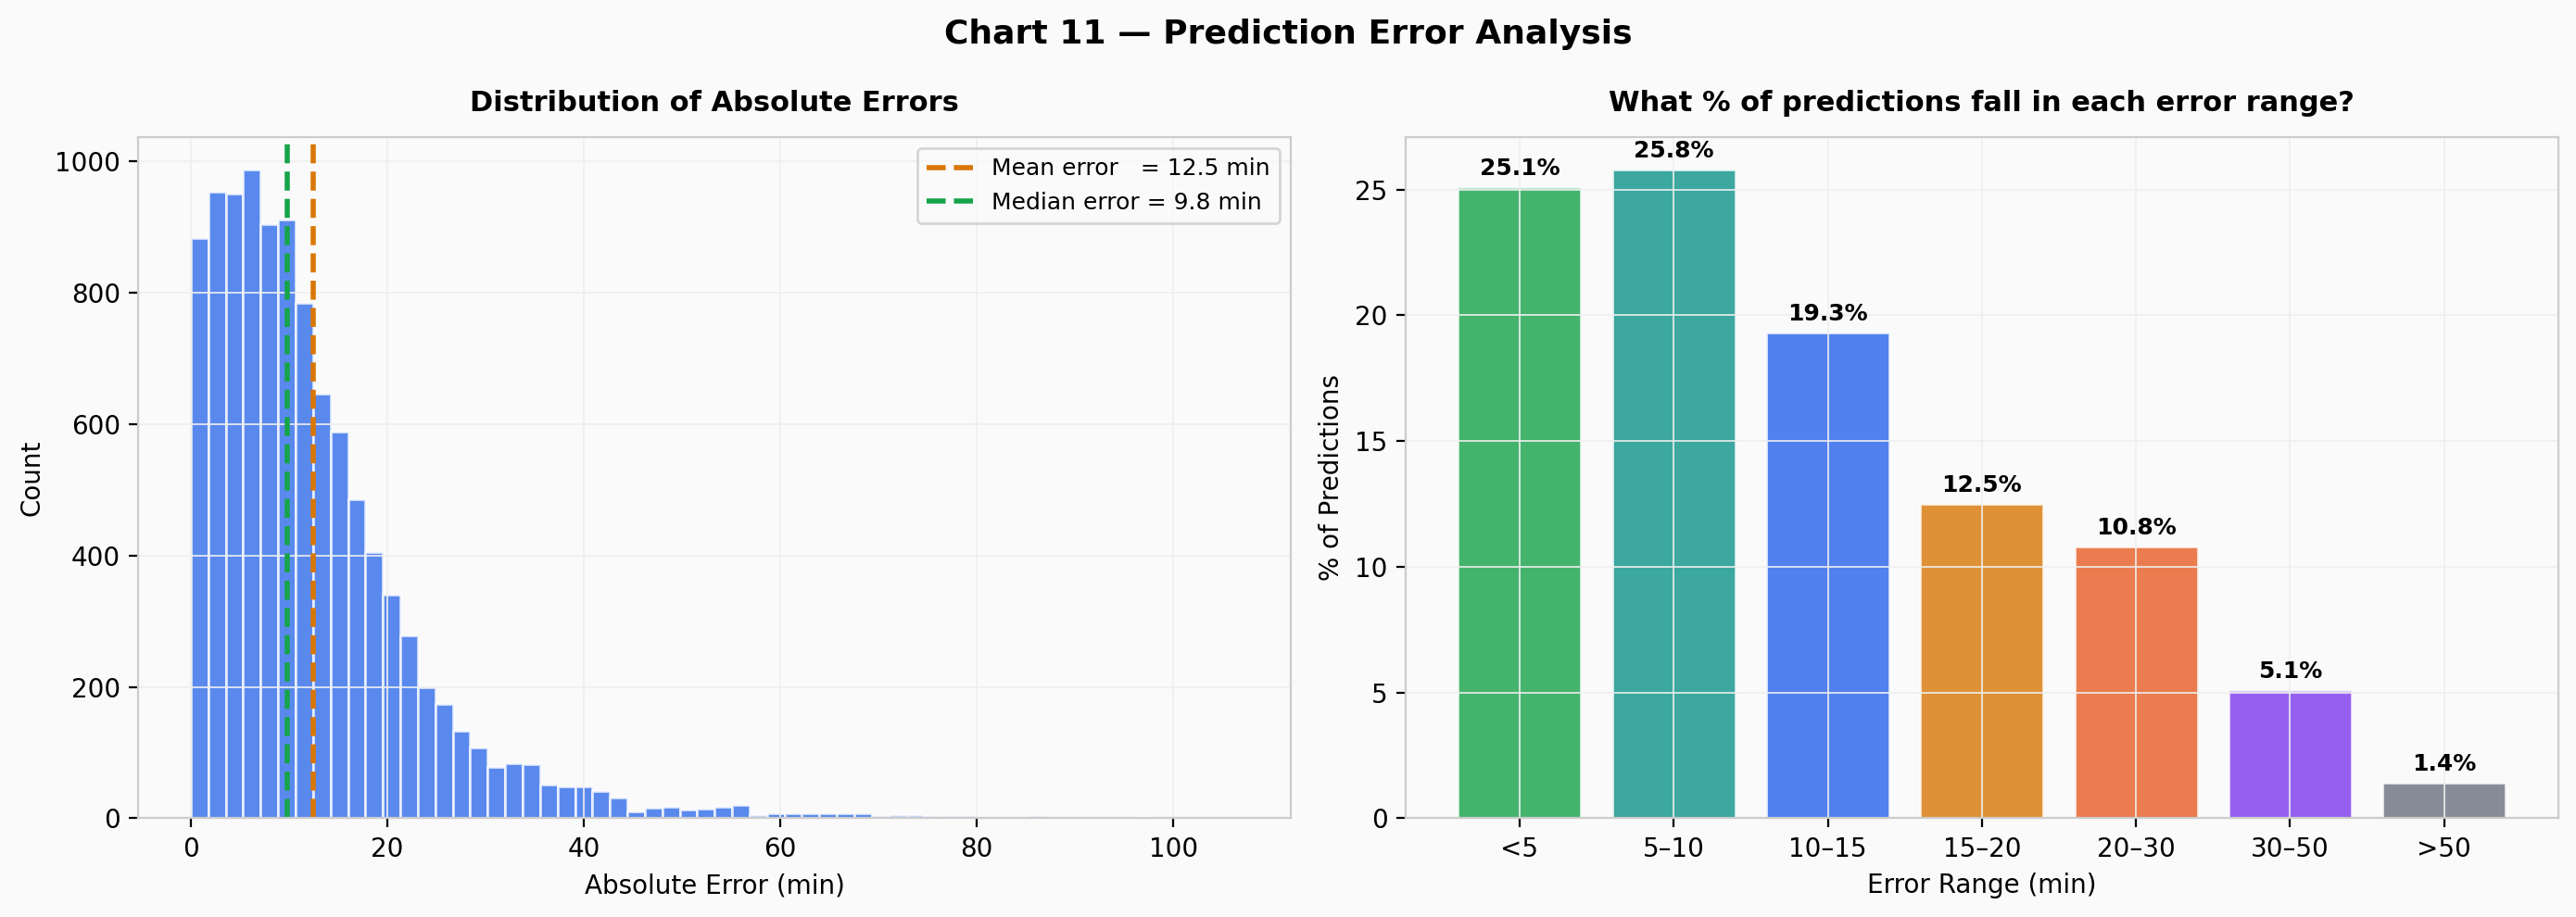

Within  5 min : 25.1%
Within 10 min : 50.8%
Within 20 min : 82.7%


In [81]:
errors = np.abs(y_test - y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 11 — Prediction Error Analysis", fontsize=13, fontweight="bold")

# Error histogram
ax = axes[0]
ax.hist(errors, bins=60, color=BLUE, alpha=0.75, edgecolor="white")
ax.axvline(errors.mean(),   color=AMBER, linestyle="--", linewidth=2,
           label=f"Mean error   = {errors.mean():.1f} min")
ax.axvline(np.median(errors), color=GREEN, linestyle="--", linewidth=2,
           label=f"Median error = {np.median(errors):.1f} min")
ax.set_xlabel("Absolute Error (min)"); ax.set_ylabel("Count")
ax.set_title("Distribution of Absolute Errors")
ax.legend(fontsize=9)

# Error buckets
ax      = axes[1]
buckets = pd.cut(errors, bins=[0,5,10,15,20,30,50,1000],
                 labels=["<5","5–10","10–15","15–20","20–30","30–50",">50"])
bucket_pct = (buckets.value_counts(sort=False) / len(errors) * 100).round(1)
bar_c = [GREEN, TEAL, BLUE, AMBER, CORAL, PURPLE, GRAY]
bars  = ax.bar(bucket_pct.index, bucket_pct.values,
               color=bar_c, alpha=0.8, edgecolor="white")
for bar, v in zip(bars, bucket_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{v}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Error Range (min)"); ax.set_ylabel("% of Predictions")
ax.set_title("What % of predictions fall in each error range?")

plt.tight_layout()
plt.show()

print(f"Within  5 min : {(errors<=5).mean()*100:.1f}%")
print(f"Within 10 min : {(errors<=10).mean()*100:.1f}%")
print(f"Within 20 min : {(errors<=20).mean()*100:.1f}%")

## 8. Save the Model

In [82]:
joblib.dump(best_model, "cargo_retrieval_best_model.pkl")
joblib.dump(FEATURES,   "cargo_retrieval_features.pkl")

print("✅ Model saved   → cargo_retrieval_best_model.pkl")
print("✅ Features saved → cargo_retrieval_features.pkl")
print(f"\n{'='*45}")
print("FINAL SUMMARY")
print(f"{'='*45}")
print(f"  Best Model : {best_name}")
print(f"  R²         : {all_results[best_name]['R2']:.4f}")
print(f"  RMSE       : {all_results[best_name]['RMSE']:.2f} min")
print(f"  MAE        : {all_results[best_name]['MAE']:.2f} min")
print(f"  Features   : {len(FEATURES)}")
print(f"  Train rows : {len(X_train):,}")
print(f"  Test rows  : {len(X_test):,}")

✅ Model saved   → cargo_retrieval_best_model.pkl
✅ Features saved → cargo_retrieval_features.pkl

FINAL SUMMARY
  Best Model : XGBoost (Tuned)
  R²         : 0.8973
  RMSE       : 16.60 min
  MAE        : 12.47 min
  Features   : 40
  Train rows : 41,600
  Test rows  : 10,400
